In [14]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')


sns.set_theme(style='whitegrid', palette='muted')
COLORS = {'no': '#e07b54', 'yes': '#378add'}


df_path = r"C:\Users\divye\Data_science_projects\5qaNUcRSLjHZ5anY\data\term-deposit-marketing-2020.csv"

df = pd.read_csv(df_path)

df.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,no
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,no
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,no
8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,no
9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,no


In [15]:
eda_df = df.copy()
eda_df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'y'],
      dtype='str')

# Feature Engineering

In [16]:
eda_df['age_group'] = pd.cut(eda_df['age'],
    bins=[17, 25, 40, 65, 100],
    labels=['18-25', '26-40', '41-65', '65+'])


# cellular contact + high balance = premium target
eda_df['cellular_wealthy'] = (
    (eda_df['contact'] == 'cellular') &
    (eda_df['balance'] > 1000)
).astype(int)

# good month + cellular = ideal timing + channel
eda_df['prime_contact'] = (
    (eda_df['contact'] == 'cellular') &
    (eda_df['month'].isin(['mar', 'oct', 'apr']))
).astype(int)

# no debt + high balance = financially free client
eda_df['financially_free'] = (
    (eda_df['housing'] == 'no') &
    (eda_df['loan'] == 'no') &
    (eda_df['balance'] > 500)
).astype(int)

# tier 1 — high quality months (rate > 10% with meaningful volume)
# tier 2 — medium months (rate 6-10% or high volume)
# tier 3 — poor months (rate < 6% or no data)

month_tier_map = {
    'apr': 1, 'feb': 1,           # good rate + volume
    'mar': 1, 'oct': 1,           # exceptional rate (keep despite low volume)
    'dec': 2,                      # okay rate, low volume
    'jun': 2, 'aug': 2, 'nov': 2, # average
    'jan': 3, 'may': 3,           # worst ROI
    'jul': 3, 'sep': 3            # poor or no data
}

eda_df['month_tier'] = eda_df['month'].map(month_tier_map)

# based on day chart analysis
HIGH_DAYS   = [2, 4, 5, 10, 17, 21, 30]   # rate up + volume present
MEDIUM_DAYS = [3, 6, 7, 8, 14, 15, 16, 20]
AVOID_DAYS  = [19, 22, 23, 24, 25, 29, 31]

eda_df['day_tier'] = eda_df['day'].apply(
    lambda d: 1 if d in HIGH_DAYS
    else 2 if d in MEDIUM_DAYS
    else 3
)

# combined timing score
# logic: good month AND good day = prime window
#        good month AND bad day  = still worth trying
#        bad month  AND good day = marginal
#        bad month  AND bad day  = avoid

eda_df['timing_score'] = eda_df.apply(
    lambda row: (
        # both good — prime window
        1 if row['month_tier'] == 1 and row['day_tier'] == 1
        # month good, day average
        else 2 if row['month_tier'] == 1 and row['day_tier'] == 2
        # month average, day good
        else 3 if row['month_tier'] == 2 and row['day_tier'] == 1
        # both average
        else 4 if row['month_tier'] == 2 and row['day_tier'] == 2
        # anything involving poor month or poor day
        else 5
    ), axis=1
)
# if timing_score = 1 is prime and 5 is worst
# LR sees higher number = worse → negative coefficient
# flip it so higher number = better

eda_df['timing_score_inv'] = 6 - eda_df['timing_score']
# now 5 = prime window, 1 = avoid
# this should flip the coefficient from red to green
# the three conditions that together give the highest
# reliable signal — cellular + young or senior + not married 26-40

def prime_trio(row):
    age     = str(row['age_group'])
    contact = str(row['contact'])
    marital = str(row['marital'])

    # tier 1 — gold combinations
    if age == '65+' and contact == 'cellular':
        return 3   # 50% rate

    if age == '18-25' and contact == 'cellular':
        return 3   # 20% rate

    if age == '65+' and marital in ['married', 'divorced']:
        return 3   # 39-65% rate

    # tier 2 — good combinations
    if contact == 'cellular' and age == '26-40':
        return 2   # 9.2% rate

    if age == '18-25' and marital == 'single':
        return 2   # 14.4% rate

    # tier 3 — dead zones
    if contact == 'unknown':
        return 0   # 3-5% across all groups

    if age == '41-65' and marital == 'married':
        return 0   # 5.7% — below base rate

    # everything else
    return 1

eda_df['prime_trio'] = eda_df.apply(prime_trio, axis=1)

prime_months = ['mar', 'apr', 'oct', 'feb']

eda_df['cellular_prime_month'] = (
    (eda_df['contact'] == 'cellular') &
    (eda_df['month'].isin(prime_months))
).astype(int)

   XGBoost — RAW COLS | DUAL RECALL THRESHOLD TUNING
   Active set       : raw cols — all 13 features
   YES recall floor : 70%
   NO  recall floor : 50%

Features in use (7) : ['day', 'month', 'contact', 'age', 'marital', 'balance', 'housing']

Dtype check after encoding:
  ✅ day             int64
  ✅ month           int64
  ✅ contact         int64
  ✅ age             int64
  ✅ marital         int64
  ✅ balance         int64
  ✅ housing         int64

✅ All features are numeric — ready for XGBoost

Train : 32000 rows (yes: 2317, no: 29683)
Test  : 8000 rows (yes: 579,  no: 7421)

scale_pos_weight : 12.81 (no=29683, yes=2317)
Model trained ✓

   THRESHOLD SCAN — YES recall vs NO recall trade-off
   ✅ = meets both floors (YES≥70% AND NO≥50%)
   Thresh  YES rec   NO rec  YES prec   YES F1    FN     FP
------------------------------------------------------------------------------
      0.05    100.0%     0.2%      7.3%    13.5%     0   7403
      0.06    100.0%     0.4%      7.3%    13.5%

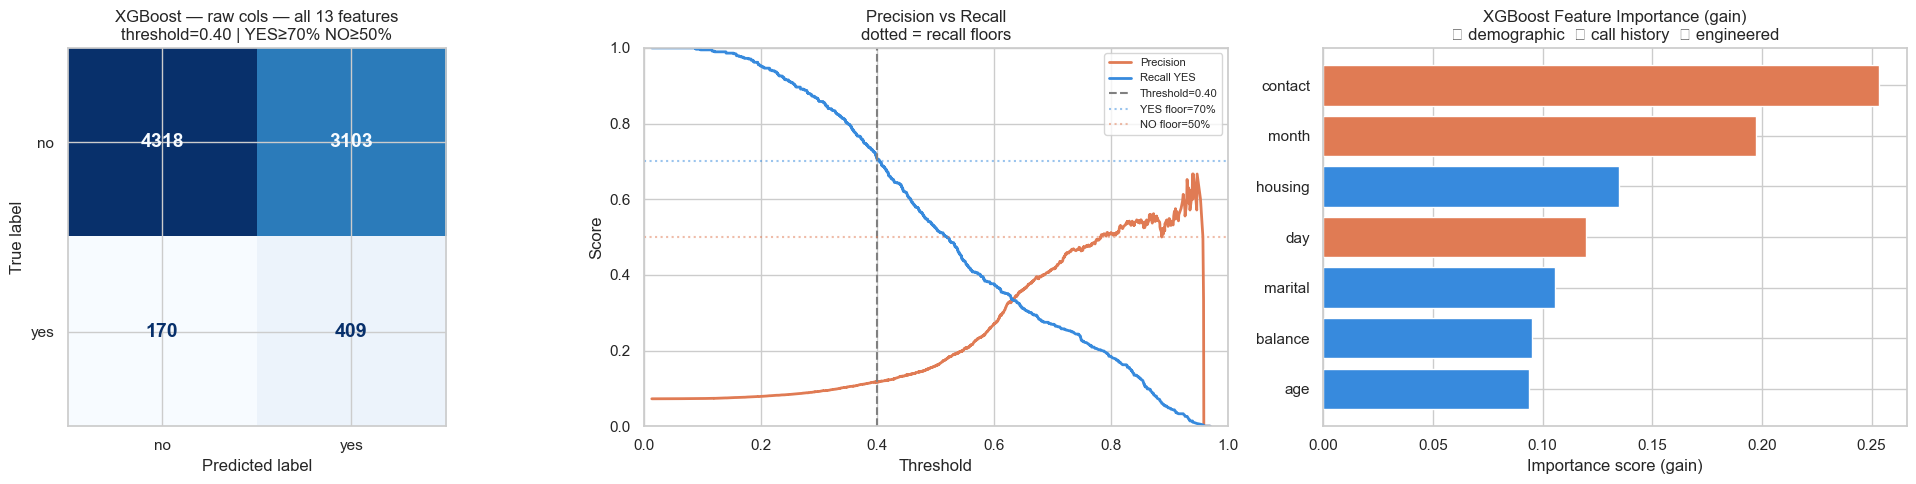

In [17]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                             confusion_matrix, precision_recall_curve)
from xgboost import XGBClassifier
import numpy as np

# ════════════════════════════════════════════════════════════════════
# FEATURE LIST — edit this manually to add or remove features
# available cols: age, job, marital, education, default, balance,
#                 housing, loan, contact, day, month, duration, campaign
# ════════════════════════════════════════════════════════════════════

ALL_FEATURES = [
   'day', 'month', 'contact', 'age', 'marital',
    'balance', 'housing'

]

ACTIVE_SET = "raw cols — all 13 features"

# ── dual recall targets ───────────────────────────────────────────────
YES_RECALL_FLOOR = 0.70
NO_RECALL_FLOOR  = 0.50

# ── colour coding for importance chart ───────────────────────────────
DEMO_COLS = ['age', 'job', 'marital', 'education',
             'default', 'balance', 'housing', 'loan']
CALL_COLS = ['contact', 'day', 'month', 'duration', 'campaign']

print("=" * 65)
print("   XGBoost — RAW COLS | DUAL RECALL THRESHOLD TUNING")
print(f"   Active set       : {ACTIVE_SET}")
print(f"   YES recall floor : {YES_RECALL_FLOOR*100:.0f}%")
print(f"   NO  recall floor : {NO_RECALL_FLOOR*100:.0f}%")
print("=" * 65)
print(f"\nFeatures in use ({len(ALL_FEATURES)}) : {ALL_FEATURES}")

# ── prepare data from eda_df — full dataset ──────────────────────────
model_df          = eda_df.copy()
model_df['y_enc'] = (model_df['y'] == 'yes').astype(int)

# ── encode categorical cols ──────────────────────────────────────────
# only encode what is in ALL_FEATURES
cat_cols_in_features = [
    c for c in ALL_FEATURES
    if model_df[c].dtype == 'object'
]

# ── fix — force encode any remaining string/object cols ─────────────
# this handles columns that may already be strings from earlier
# notebook cells or that LabelEncoder missed

le = LabelEncoder()
for col in ALL_FEATURES:
    if model_df[col].dtype == 'object' or model_df[col].dtype.name == 'str':
        model_df[col] = le.fit_transform(model_df[col].astype(str))
    elif model_df[col].dtype.name == 'category':
        model_df[col] = le.fit_transform(model_df[col].astype(str))

# verify all features are numeric now
print("\nDtype check after encoding:")
for col in ALL_FEATURES:
    dtype = model_df[col].dtype
    status = '✅' if dtype in ['int64', 'int32', 'float64', 'float32',
                                'int8', 'uint8'] else '❌'
    print(f"  {status} {col:<15} {str(dtype)}")

# confirm no object dtypes remain
remaining_obj = [c for c in ALL_FEATURES
                 if model_df[c].dtype == 'object'
                 or model_df[c].dtype.name == 'category'
                 or model_df[c].dtype.name == 'str']

if remaining_obj:
    print(f"\n⚠️  Still non-numeric: {remaining_obj}")
    print("  Force converting with pd.factorize...")
    for col in remaining_obj:
        model_df[col], _ = pd.factorize(model_df[col])
        print(f"  Fixed: {col} → {model_df[col].dtype}")
else:
    print("\n✅ All features are numeric — ready for XGBoost")

# ── X and y ──────────────────────────────────────────────────────────
X = model_df[ALL_FEATURES]
y = model_df['y_enc']

# ── train test split ─────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTrain : {X_train.shape[0]} rows "
      f"(yes: {y_train.sum()}, no: {(y_train==0).sum()})")
print(f"Test  : {X_test.shape[0]} rows "
      f"(yes: {y_test.sum()},  no: {(y_test==0).sum()})")

# ── scale_pos_weight ──────────────────────────────────────────────────
neg_count   = (y_train == 0).sum()
pos_count   = (y_train == 1).sum()
scale_pos_w = neg_count / pos_count

print(f"\nscale_pos_weight : {scale_pos_w:.2f} "
      f"(no={neg_count}, yes={pos_count})")

# ── train XGBoost ─────────────────────────────────────────────────────
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=scale_pos_w,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb.fit(X_train, y_train)
print("Model trained ✓")

# ── dual recall threshold search ─────────────────────────────────────
y_prob = xgb.predict_proba(X_test)[:, 1]
precision_arr, recall_arr, thresholds_arr = precision_recall_curve(
    y_test, y_prob)

best_threshold = 0.3
best_yes_f1    = 0
threshold_log  = []

for thresh in np.arange(0.05, 0.80, 0.01):
    preds = (y_prob >= thresh).astype(int)
    cm_t  = confusion_matrix(y_test, preds)
    if cm_t.shape == (2, 2):
        tn_t, fp_t, fn_t, tp_t = cm_t.ravel()

        yes_rec  = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
        no_rec   = tn_t / (tn_t + fp_t) if (tn_t + fp_t) > 0 else 0
        yes_prec = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
        yes_f1   = (2 * yes_prec * yes_rec /
                   (yes_prec + yes_rec)
                   if (yes_prec + yes_rec) > 0 else 0)

        threshold_log.append({
            'threshold': round(thresh, 2),
            'yes_recall': round(yes_rec  * 100, 1),
            'no_recall' : round(no_rec   * 100, 1),
            'yes_prec'  : round(yes_prec * 100, 1),
            'yes_f1'    : round(yes_f1   * 100, 1),
            'fn'        : fn_t,
            'fp'        : fp_t,
            'valid'     : (yes_rec >= YES_RECALL_FLOOR
                           and no_rec >= NO_RECALL_FLOOR)
        })

        if (yes_rec >= YES_RECALL_FLOOR
                and no_rec >= NO_RECALL_FLOOR
                and yes_f1 > best_yes_f1):
            best_yes_f1    = yes_f1
            best_threshold = thresh

# ── threshold scan table ──────────────────────────────────────────────
print("\n" + "=" * 78)
print("   THRESHOLD SCAN — YES recall vs NO recall trade-off")
print(f"   ✅ = meets both floors "
      f"(YES≥{YES_RECALL_FLOOR*100:.0f}% AND NO≥{NO_RECALL_FLOOR*100:.0f}%)")
print("=" * 78)
print(f"  {'Thresh':>7} {'YES rec':>8} {'NO rec':>8} "
      f"{'YES prec':>9} {'YES F1':>8} {'FN':>5} {'FP':>6}")
print("-" * 78)

for row in threshold_log:
    tag = '✅' if row['valid'] else '  '
    print(f"  {tag} {row['threshold']:>5.2f}   "
          f"{row['yes_recall']:>6.1f}%  "
          f"{row['no_recall']:>6.1f}%  "
          f"{row['yes_prec']:>7.1f}%  "
          f"{row['yes_f1']:>6.1f}%  "
          f"{row['fn']:>4}  {row['fp']:>5}")

print("=" * 78)
print(f"\n  Auto-selected threshold : {best_threshold:.2f}")
print(f"  Reasoning : best YES F1 while "
      f"YES≥{YES_RECALL_FLOOR*100:.0f}% AND NO≥{NO_RECALL_FLOOR*100:.0f}%")

THRESHOLD    = best_threshold
y_pred_tuned = (y_prob >= THRESHOLD).astype(int)

# ── classification report ─────────────────────────────────────────────
report = classification_report(
    y_test, y_pred_tuned,
    target_names=['no', 'yes'],
    output_dict=True)

print(f"\nClassification Report (threshold = {THRESHOLD:.2f}):")
print(classification_report(y_test, y_pred_tuned,
      target_names=['no', 'yes']))

# ── confusion matrix breakdown ───────────────────────────────────────
cm             = confusion_matrix(y_test, y_pred_tuned)
tn, fp, fn, tp = cm.ravel()

no_precision  = tn / (tn + fn)  if (tn + fn) > 0 else 0
no_recall     = tn / (tn + fp)  if (tn + fp) > 0 else 0
no_f1         = (2 * no_precision * no_recall /
                 (no_precision + no_recall)
                 if (no_precision + no_recall) > 0 else 0)
yes_precision = tp / (tp + fp)  if (tp + fp) > 0 else 0
yes_recall    = tp / (tp + fn)  if (tp + fn) > 0 else 0
yes_f1        = (2 * yes_precision * yes_recall /
                 (yes_precision + yes_recall)
                 if (yes_precision + yes_recall) > 0 else 0)
accuracy      = (tn + tp) / (tn + fp + fn + tp)

print("=" * 60)
print("            CONFUSION MATRIX BREAKDOWN")
print("=" * 60)
print(f"  True  Negative (TN) : {tn:>6}  — correctly predicted NO")
print(f"  False Positive (FP) : {fp:>6}  — said YES but actually NO")
print(f"  False Negative (FN) : {fn:>6}  — said NO but actually YES  ← minimise")
print(f"  True  Positive (TP) : {tp:>6}  — correctly predicted YES")
print("=" * 60)
print(f"  Overall Accuracy    : {accuracy*100:.1f}%")
print("=" * 60)

print("\n" + "=" * 60)
print("       FULL CLASSIFICATION REPORT BY CLASS")
print("=" * 60)
print(f"  {'Metric':<18} {'NO (class 0)':>15} {'YES (class 1)':>15}")
print("-" * 60)
print(f"  {'Precision':<18} {no_precision*100:>14.1f}% {yes_precision*100:>14.1f}%")
print(f"  {'Recall':<18} {no_recall*100:>14.1f}% {yes_recall*100:>14.1f}%")
print(f"  {'F1 Score':<18} {no_f1*100:>14.1f}% {yes_f1*100:>14.1f}%")
print(f"  {'Support':<18} {tn+fp:>15} {tp+fn:>15}")
print("=" * 60)
print(f"\n  ► YES recall floor set : {YES_RECALL_FLOOR*100:.0f}%")
print(f"  ► NO  recall floor set : {NO_RECALL_FLOOR*100:.0f}%")
print(f"  ► Recall YES achieved  : {yes_recall*100:.1f}%")
print(f"  ► Recall NO  achieved  : {no_recall*100:.1f}%")
print(f"  ► FN (missed yes)      : {fn}")
print(f"  ► FP (noise)           : {fp}")
print("=" * 60)

# ── plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tuned,
    display_labels=['no', 'yes'],
    cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title(f'XGBoost — {ACTIVE_SET}\n'
                  f'threshold={THRESHOLD:.2f} | '
                  f'YES≥{YES_RECALL_FLOOR*100:.0f}% '
                  f'NO≥{NO_RECALL_FLOOR*100:.0f}%')
for text in axes[0].texts:
    text.set_fontsize(14)
    text.set_fontweight('bold')

axes[1].plot(thresholds_arr, precision_arr[:-1],
             label='Precision', color='#e07b54', linewidth=2)
axes[1].plot(thresholds_arr, recall_arr[:-1],
             label='Recall YES', color='#378add', linewidth=2)
axes[1].axvline(x=THRESHOLD, color='gray', linestyle='--',
                label=f'Threshold={THRESHOLD:.2f}')
axes[1].axhline(y=YES_RECALL_FLOOR, color='#378add',
                linestyle=':', alpha=0.5,
                label=f'YES floor={YES_RECALL_FLOOR*100:.0f}%')
axes[1].axhline(y=NO_RECALL_FLOOR, color='#e07b54',
                linestyle=':', alpha=0.5,
                label=f'NO floor={NO_RECALL_FLOOR*100:.0f}%')
axes[1].set_title('Precision vs Recall\ndotted = recall floors')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].legend(fontsize=8)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

imp_df = pd.DataFrame({
    'feature'   : ALL_FEATURES,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=True)

colors = ['#378add' if f in DEMO_COLS
          else '#e07b54' if f in CALL_COLS
          else '#2ecc71'
          for f in imp_df['feature']]

axes[2].barh(imp_df['feature'], imp_df['importance'],
             color=colors, edgecolor='white')
axes[2].set_title('XGBoost Feature Importance (gain)\n'
                  '🔵 demographic  🟠 call history  🟢 engineered')
axes[2].set_xlabel('Importance score (gain)')
plt.tight_layout()
plt.show()

   Random Forest — RAW COLS | DUAL RECALL THRESHOLD TUNING
   Active set       : raw cols — all 13 features
   YES recall floor : 80%
   NO  recall floor : 50%

Features in use (7) : ['day', 'month', 'contact', 'age', 'marital', 'balance', 'housing']

Dtype check after encoding:
  ✅ day             int64
  ✅ month           int64
  ✅ contact         int64
  ✅ age             int64
  ✅ marital         int64
  ✅ balance         int64
  ✅ housing         int64

✅ All features are numeric — ready for Random Forest

Train : 32000 rows (yes: 2317, no: 29683)
Test  : 8000 rows (yes: 579,  no: 7421)

Class weight : 'balanced'  (no=29683, yes=2317)
Model trained ✓

   THRESHOLD SCAN — YES recall vs NO recall trade-off
   ✅ = meets both floors (YES≥80% AND NO≥50%)
   Thresh  YES rec   NO rec  YES prec   YES F1    FN     FP
------------------------------------------------------------------------------
      0.05    100.0%     0.0%      7.2%    13.5%     0   7421
      0.06    100.0%     0.0%     

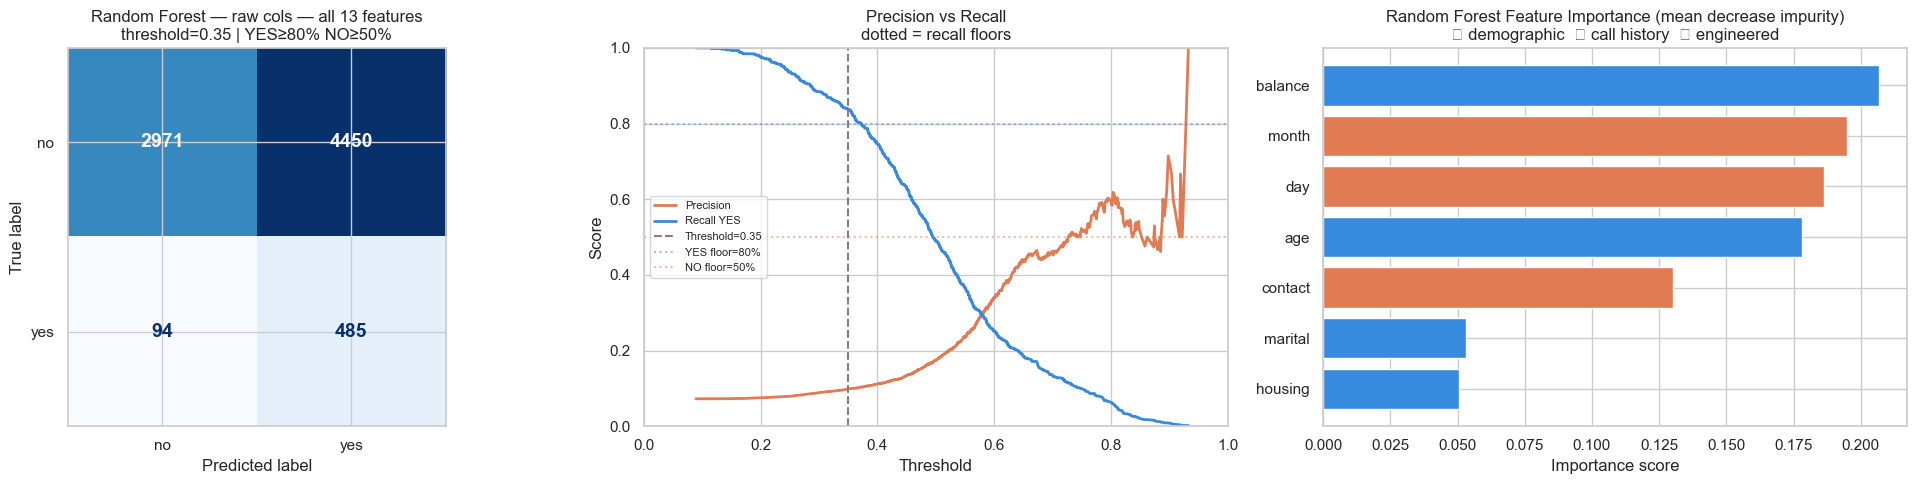

In [18]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                             confusion_matrix, precision_recall_curve)
import numpy as np

# ════════════════════════════════════════════════════════════════════
# FEATURE LIST — edit this manually to add or remove features
# available cols: age, job, marital, education, default, balance,
#                 housing, loan, contact, day, month, duration, campaign
# ════════════════════════════════════════════════════════════════════

ALL_FEATURES = [
   'day', 'month','contact','age', 'marital', 'balance','housing'
]

ACTIVE_SET = "raw cols — all 13 features"

# ── dual recall targets ───────────────────────────────────────────────
YES_RECALL_FLOOR = 0.80
NO_RECALL_FLOOR  = 0.50

# ── colour coding for importance chart ───────────────────────────────
DEMO_COLS = ['age', 'job', 'marital', 'education',
             'default', 'balance', 'housing', 'loan']
CALL_COLS = ['contact', 'day', 'month', 'duration', 'campaign']

print("=" * 65)
print("   Random Forest — RAW COLS | DUAL RECALL THRESHOLD TUNING")
print(f"   Active set       : {ACTIVE_SET}")
print(f"   YES recall floor : {YES_RECALL_FLOOR*100:.0f}%")
print(f"   NO  recall floor : {NO_RECALL_FLOOR*100:.0f}%")
print("=" * 65)
print(f"\nFeatures in use ({len(ALL_FEATURES)}) : {ALL_FEATURES}")

# ── prepare data ──────────────────────────────────────────────────────
model_df          = eda_df.copy()
model_df['y_enc'] = (model_df['y'] == 'yes').astype(int)

# ── encode categorical / category cols ───────────────────────────────
le = LabelEncoder()
for col in ALL_FEATURES:
    if (model_df[col].dtype == 'object'
            or model_df[col].dtype.name in ('str', 'category')):
        model_df[col] = le.fit_transform(model_df[col].astype(str))

# ── dtype check ──────────────────────────────────────────────────────
print("\nDtype check after encoding:")
for col in ALL_FEATURES:
    dtype  = model_df[col].dtype
    status = '✅' if dtype in ['int64', 'int32', 'float64', 'float32',
                                'int8', 'uint8'] else '❌'
    print(f"  {status} {col:<15} {str(dtype)}")

remaining_obj = [c for c in ALL_FEATURES
                 if model_df[c].dtype == 'object'
                 or model_df[c].dtype.name in ('category', 'str')]
if remaining_obj:
    print(f"\n⚠️  Still non-numeric: {remaining_obj} — force-factorizing...")
    for col in remaining_obj:
        model_df[col], _ = pd.factorize(model_df[col])
        print(f"  Fixed: {col} → {model_df[col].dtype}")
else:
    print("\n✅ All features are numeric — ready for Random Forest")

# ── X / y ─────────────────────────────────────────────────────────────
X = model_df[ALL_FEATURES]
y = model_df['y_enc']

# ── train / test split ────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTrain : {X_train.shape[0]} rows "
      f"(yes: {y_train.sum()}, no: {(y_train==0).sum()})")
print(f"Test  : {X_test.shape[0]} rows "
      f"(yes: {y_test.sum()},  no: {(y_test==0).sum()})")

# ── class weight ─────────────────────────────────────────────────────
# RF uses class_weight='balanced' — equivalent to XGB's scale_pos_weight
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
print(f"\nClass weight : 'balanced'  (no={neg_count}, yes={pos_count})")

# ── train Random Forest ───────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    max_features='sqrt',          # same spirit as colsample_bytree
    class_weight='balanced',      # handles imbalance like scale_pos_weight
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
print("Model trained ✓")

# ── dual recall threshold search ─────────────────────────────────────
y_prob = rf.predict_proba(X_test)[:, 1]
precision_arr, recall_arr, thresholds_arr = precision_recall_curve(
    y_test, y_prob)

best_threshold = 0.35
best_yes_f1    = 0
threshold_log  = []

for thresh in np.arange(0.05, 0.80, 0.01):
    preds = (y_prob >= thresh).astype(int)
    cm_t  = confusion_matrix(y_test, preds)
    if cm_t.shape == (2, 2):
        tn_t, fp_t, fn_t, tp_t = cm_t.ravel()

        yes_rec  = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
        no_rec   = tn_t / (tn_t + fp_t) if (tn_t + fp_t) > 0 else 0
        yes_prec = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
        yes_f1   = (2 * yes_prec * yes_rec /
                    (yes_prec + yes_rec)
                    if (yes_prec + yes_rec) > 0 else 0)

        threshold_log.append({
            'threshold': round(thresh, 2),
            'yes_recall': round(yes_rec  * 100, 1),
            'no_recall' : round(no_rec   * 100, 1),
            'yes_prec'  : round(yes_prec * 100, 1),
            'yes_f1'    : round(yes_f1   * 100, 1),
            'fn'        : fn_t,
            'fp'        : fp_t,
            'valid'     : (yes_rec >= YES_RECALL_FLOOR
                           and no_rec >= NO_RECALL_FLOOR)
        })

        if (yes_rec >= YES_RECALL_FLOOR
                and no_rec >= NO_RECALL_FLOOR
                and yes_f1 > best_yes_f1):
            best_yes_f1    = yes_f1
            best_threshold = thresh

# ── threshold scan table ──────────────────────────────────────────────
print("\n" + "=" * 78)
print("   THRESHOLD SCAN — YES recall vs NO recall trade-off")
print(f"   ✅ = meets both floors "
      f"(YES≥{YES_RECALL_FLOOR*100:.0f}% AND NO≥{NO_RECALL_FLOOR*100:.0f}%)")
print("=" * 78)
print(f"  {'Thresh':>7} {'YES rec':>8} {'NO rec':>8} "
      f"{'YES prec':>9} {'YES F1':>8} {'FN':>5} {'FP':>6}")
print("-" * 78)

for row in threshold_log:
    tag = '✅' if row['valid'] else '  '
    print(f"  {tag} {row['threshold']:>5.2f}   "
          f"{row['yes_recall']:>6.1f}%  "
          f"{row['no_recall']:>6.1f}%  "
          f"{row['yes_prec']:>7.1f}%  "
          f"{row['yes_f1']:>6.1f}%  "
          f"{row['fn']:>4}  {row['fp']:>5}")

print("=" * 78)
print(f"\n  Auto-selected threshold : {best_threshold:.2f}")
print(f"  Reasoning : best YES F1 while "
      f"YES≥{YES_RECALL_FLOOR*100:.0f}% AND NO≥{NO_RECALL_FLOOR*100:.0f}%")

THRESHOLD    = best_threshold
y_pred_tuned = (y_prob >= THRESHOLD).astype(int)

# ── classification report ─────────────────────────────────────────────
print(f"\nClassification Report (threshold = {THRESHOLD:.2f}):")
print(classification_report(y_test, y_pred_tuned,
      target_names=['no', 'yes']))

# ── confusion matrix breakdown ────────────────────────────────────────
cm             = confusion_matrix(y_test, y_pred_tuned)
tn, fp, fn, tp = cm.ravel()

no_precision  = tn / (tn + fn)  if (tn + fn) > 0 else 0
no_recall     = tn / (tn + fp)  if (tn + fp) > 0 else 0
no_f1         = (2 * no_precision * no_recall /
                 (no_precision + no_recall)
                 if (no_precision + no_recall) > 0 else 0)
yes_precision = tp / (tp + fp)  if (tp + fp) > 0 else 0
yes_recall    = tp / (tp + fn)  if (tp + fn) > 0 else 0
yes_f1        = (2 * yes_precision * yes_recall /
                 (yes_precision + yes_recall)
                 if (yes_precision + yes_recall) > 0 else 0)
accuracy      = (tn + tp) / (tn + fp + fn + tp)

print("=" * 60)
print("            CONFUSION MATRIX BREAKDOWN")
print("=" * 60)
print(f"  True  Negative (TN) : {tn:>6}  — correctly predicted NO")
print(f"  False Positive (FP) : {fp:>6}  — said YES but actually NO")
print(f"  False Negative (FN) : {fn:>6}  — said NO but actually YES  ← minimise")
print(f"  True  Positive (TP) : {tp:>6}  — correctly predicted YES")
print("=" * 60)
print(f"  Overall Accuracy    : {accuracy*100:.1f}%")
print("=" * 60)

print("\n" + "=" * 60)
print("       FULL CLASSIFICATION REPORT BY CLASS")
print("=" * 60)
print(f"  {'Metric':<18} {'NO (class 0)':>15} {'YES (class 1)':>15}")
print("-" * 60)
print(f"  {'Precision':<18} {no_precision*100:>14.1f}% {yes_precision*100:>14.1f}%")
print(f"  {'Recall':<18} {no_recall*100:>14.1f}% {yes_recall*100:>14.1f}%")
print(f"  {'F1 Score':<18} {no_f1*100:>14.1f}% {yes_f1*100:>14.1f}%")
print(f"  {'Support':<18} {tn+fp:>15} {tp+fn:>15}")
print("=" * 60)
print(f"\n  ► YES recall floor set : {YES_RECALL_FLOOR*100:.0f}%")
print(f"  ► NO  recall floor set : {NO_RECALL_FLOOR*100:.0f}%")
print(f"  ► Recall YES achieved  : {yes_recall*100:.1f}%")
print(f"  ► Recall NO  achieved  : {no_recall*100:.1f}%")
print(f"  ► FN (missed yes)      : {fn}")
print(f"  ► FP (noise)           : {fp}")
print("=" * 60)

# ── plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tuned,
    display_labels=['no', 'yes'],
    cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title(f'Random Forest — {ACTIVE_SET}\n'
                  f'threshold={THRESHOLD:.2f} | '
                  f'YES≥{YES_RECALL_FLOOR*100:.0f}% '
                  f'NO≥{NO_RECALL_FLOOR*100:.0f}%')
for text in axes[0].texts:
    text.set_fontsize(14)
    text.set_fontweight('bold')

axes[1].plot(thresholds_arr, precision_arr[:-1],
             label='Precision', color='#e07b54', linewidth=2)
axes[1].plot(thresholds_arr, recall_arr[:-1],
             label='Recall YES', color='#378add', linewidth=2)
axes[1].axvline(x=THRESHOLD, color='gray', linestyle='--',
                label=f'Threshold={THRESHOLD:.2f}')
axes[1].axhline(y=YES_RECALL_FLOOR, color='#378add',
                linestyle=':', alpha=0.5,
                label=f'YES floor={YES_RECALL_FLOOR*100:.0f}%')
axes[1].axhline(y=NO_RECALL_FLOOR, color='#e07b54',
                linestyle=':', alpha=0.5,
                label=f'NO floor={NO_RECALL_FLOOR*100:.0f}%')
axes[1].set_title('Precision vs Recall\ndotted = recall floors')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].legend(fontsize=8)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

imp_df = pd.DataFrame({
    'feature'   : ALL_FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

colors = ['#378add' if f in DEMO_COLS
          else '#e07b54' if f in CALL_COLS
          else '#2ecc71'
          for f in imp_df['feature']]

axes[2].barh(imp_df['feature'], imp_df['importance'],
             color=colors, edgecolor='white')
axes[2].set_title('Random Forest Feature Importance (mean decrease impurity)\n'
                  '🔵 demographic  🟠 call history  🟢 engineered')
axes[2].set_xlabel('Importance score')

plt.tight_layout()
plt.show()

   Neural Network — DUAL RECALL THRESHOLD TUNING
   Active set       : raw + engineered | no duration | no campaign
   YES recall floor : 80%
   NO  recall floor : 50%

Features in use (7) : ['age', 'balance', 'day', 'marital', 'housing', 'contact', 'month']

Categorical cols (4) : ['marital', 'housing', 'contact', 'month']
Numeric cols    (3) : ['age', 'balance', 'day']

Features after one-hot encoding : 22

Dtype check (sample):
  age                            int64
  balance                        int64
  day                            int64
  marital_divorced               bool
  marital_married                bool
  ... and 17 more

Train : 32000 rows (yes: 2317, no: 29683)
Test  : 8000 rows (yes: 579,  no: 7421)

Class weights : {0: 1.00, 1: 12.81}


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 22)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,081 (55.00 KB)

 Trainable params: 13,697 (53.50 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - AUC: 0.5829 - loss: 1.3992 - recall: 0.5650 - val_AUC: 0.6419 - val_loss: 0.6316 - val_recall: 0.3437 - learning_rate: 0.0010
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.6364 - loss: 1.2661 - recall: 0.5757 - val_AUC: 0.6810 - val_loss: 0.6071 - val_recall: 0.4318 - learning_rate: 0.0010
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.6393 - loss: 1.2453 - recall: 0.5753 - val_AUC: 0.7035 - val_loss: 0.5705 - val_recall: 0.4853 - learning_rate: 0.0010
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.6614 - loss: 1.2138 - recall: 0.5848 - val_AUC: 0.7072 - val_loss: 0.5587 - val_recall: 0.4991 - learning_rate: 0.0010
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.6669 - loss: 1.2038 - recall: 0.5775 - val_AUC: 0.7148 - val_loss: 0.5609 - val_recall: 0.5078 - learning_rate: 0.0010
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.6824 - loss: 1.1837 - recall: 0.

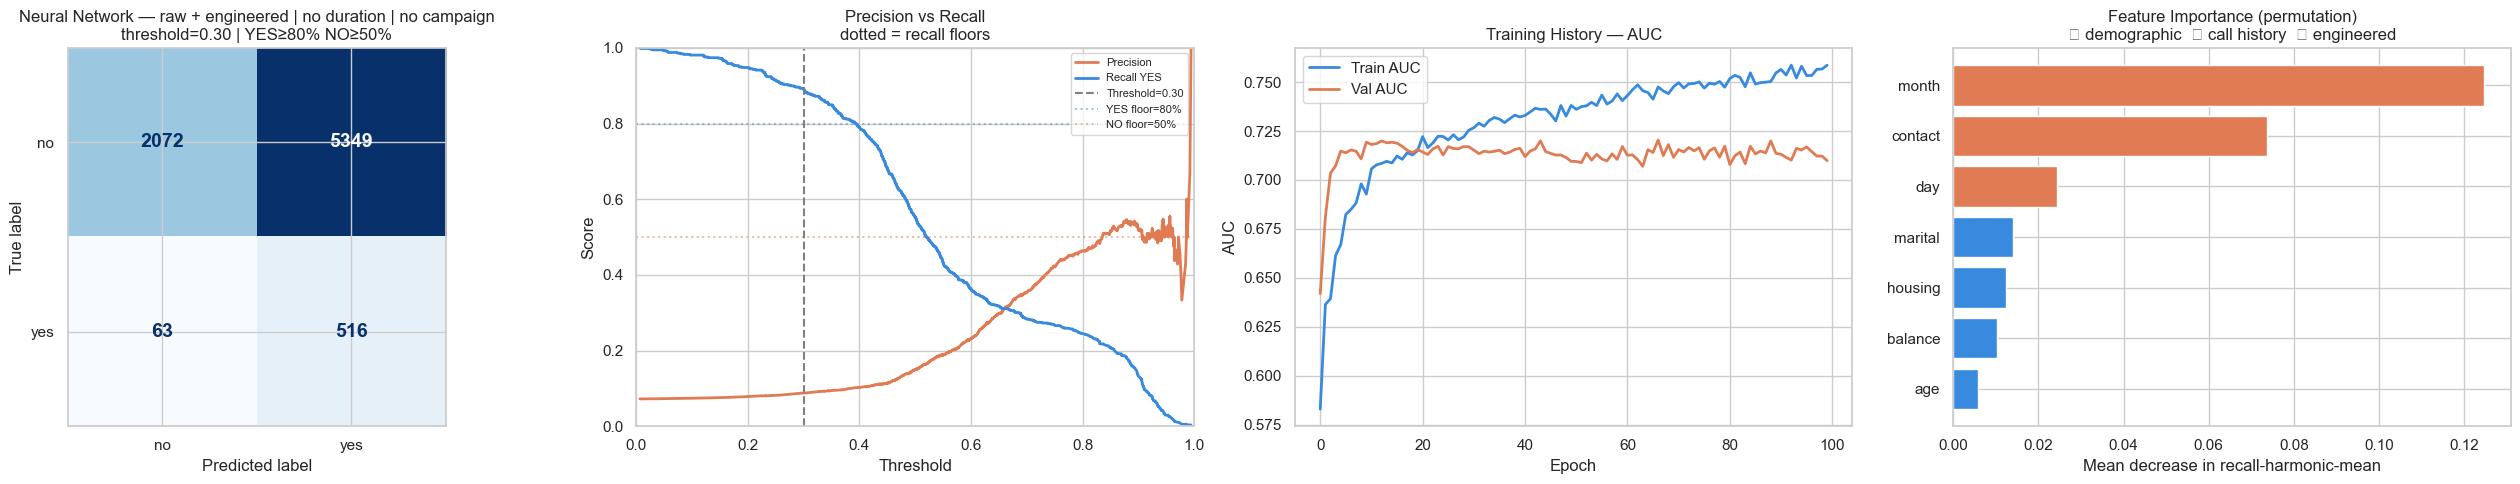

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                             confusion_matrix, precision_recall_curve)
from sklearn.inspection import permutation_importance

import keras
from keras import layers
import tensorflow as tf

tf.random.set_seed(42)
np.random.seed(42)

# ════════════════════════════════════════════════════════════════════
# FEATURE LIST — same pattern as RF/XGBoost
# ════════════════════════════════════════════════════════════════════

ALL_FEATURES = [
    # raw numeric
    'age', 'balance', 'day', 'marital',
    'housing', 'contact', 'month'
   
]

ACTIVE_SET = "raw + engineered | no duration | no campaign"

# ── dual recall targets ───────────────────────────────────────────────
YES_RECALL_FLOOR = 0.80
NO_RECALL_FLOOR  = 0.50

# ── colour coding for importance chart ───────────────────────────────
DEMO_COLS = ['age', 'job', 'marital', 'education',
             'default', 'balance', 'housing', 'loan']
CALL_COLS = ['contact', 'day', 'month', 'duration', 'campaign']

print("=" * 65)
print("   Neural Network — DUAL RECALL THRESHOLD TUNING")
print(f"   Active set       : {ACTIVE_SET}")
print(f"   YES recall floor : {YES_RECALL_FLOOR*100:.0f}%")
print(f"   NO  recall floor : {NO_RECALL_FLOOR*100:.0f}%")
print("=" * 65)
print(f"\nFeatures in use ({len(ALL_FEATURES)}) : {ALL_FEATURES}")

# ── prepare data ──────────────────────────────────────────────────────
model_df          = eda_df.copy()
model_df['y_enc'] = (model_df['y'] == 'yes').astype(int)

# ── encode categoricals ───────────────────────────────────────────────
# Explicitly define cat cols — avoids dtype detection issues with
# pd.Categorical (from pd.cut) being silently dropped by get_dummies
CAT_COLS = ['job', 'marital', 'education', 'default',
            'housing', 'loan', 'contact', 'month', 'age_group']
# keep only those actually present in ALL_FEATURES
CAT_COLS = [c for c in CAT_COLS if c in ALL_FEATURES]
NUM_COLS = [c for c in ALL_FEATURES if c not in CAT_COLS]

print(f"\nCategorical cols ({len(CAT_COLS)}) : {CAT_COLS}")
print(f"Numeric cols    ({len(NUM_COLS)}) : {NUM_COLS}")

# force-cast all cat cols to str — handles pd.Categorical from pd.cut
for col in CAT_COLS:
    model_df[col] = model_df[col].astype(str)

# one-hot encode categoricals
model_enc = pd.get_dummies(model_df[ALL_FEATURES + ['y_enc']],
                           columns=CAT_COLS,
                           drop_first=False)

# track final feature columns (everything except target)
FINAL_FEATURES = [c for c in model_enc.columns if c != 'y_enc']
print(f"\nFeatures after one-hot encoding : {len(FINAL_FEATURES)}")

# ── dtype check ──────────────────────────────────────────────────────
print("\nDtype check (sample):")
for col in FINAL_FEATURES[:5]:
    print(f"  {col:<30} {str(model_enc[col].dtype)}")
print(f"  ... and {len(FINAL_FEATURES)-5} more")

# ── X / y ─────────────────────────────────────────────────────────────
X = model_enc[FINAL_FEATURES].values.astype(np.float32)
y = model_enc['y_enc'].values

# ── train / test split ────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTrain : {X_train.shape[0]} rows "
      f"(yes: {y_train.sum()}, no: {(y_train==0).sum()})")
print(f"Test  : {X_test.shape[0]} rows "
      f"(yes: {y_test.sum()},  no: {(y_test==0).sum()})")

# ── scale numeric features only ───────────────────────────────────────
# identify which columns in FINAL_FEATURES came from NUM_COLS
num_idx = [FINAL_FEATURES.index(c) for c in NUM_COLS if c in FINAL_FEATURES]

scaler = StandardScaler()
X_train[:, num_idx] = scaler.fit_transform(X_train[:, num_idx])
X_test[:, num_idx]  = scaler.transform(X_test[:, num_idx])

# ── class weights ──────────────────────────────────────────────────────
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
weight_for_0 = 1.0
weight_for_1 = neg_count / pos_count   # same logic as scale_pos_weight
class_weight = {0: weight_for_0, 1: weight_for_1}
print(f"\nClass weights : {{0: {weight_for_0:.2f}, 1: {weight_for_1:.2f}}}")

# ── build model ───────────────────────────────────────────────────────
def build_model(input_dim):
    inputs = keras.Input(shape=(input_dim,))

    x = layers.Dense(128, activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(64, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.2)(x)

    output = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs, output)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['AUC', keras.metrics.Recall(name='recall')]
    )
    return model

nn_model = build_model(X_train.shape[1])
nn_model.summary()

# ── train ─────────────────────────────────────────────────────────────
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_auc', patience=15,
    restore_best_weights=True, mode='max')

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_auc', patience=7,
    factor=0.5, min_lr=1e-5, mode='max')

history = nn_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=256,
    class_weight=class_weight,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
print("Model trained ✓")

# ── dual recall threshold search ─────────────────────────────────────
y_prob = nn_model.predict(X_test, verbose=0).ravel()
precision_arr, recall_arr, thresholds_arr = precision_recall_curve(
    y_test, y_prob)

best_threshold = 0.3
best_yes_f1    = 0
threshold_log  = []

for thresh in np.arange(0.05, 0.80, 0.01):
    preds = (y_prob >= thresh).astype(int)
    cm_t  = confusion_matrix(y_test, preds)
    if cm_t.shape == (2, 2):
        tn_t, fp_t, fn_t, tp_t = cm_t.ravel()

        yes_rec  = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
        no_rec   = tn_t / (tn_t + fp_t) if (tn_t + fp_t) > 0 else 0
        yes_prec = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
        yes_f1   = (2 * yes_prec * yes_rec /
                    (yes_prec + yes_rec)
                    if (yes_prec + yes_rec) > 0 else 0)

        threshold_log.append({
            'threshold': round(thresh, 2),
            'yes_recall': round(yes_rec  * 100, 1),
            'no_recall' : round(no_rec   * 100, 1),
            'yes_prec'  : round(yes_prec * 100, 1),
            'yes_f1'    : round(yes_f1   * 100, 1),
            'fn'        : fn_t,
            'fp'        : fp_t,
            'valid'     : (yes_rec >= YES_RECALL_FLOOR
                           and no_rec >= NO_RECALL_FLOOR)
        })

        if (yes_rec >= YES_RECALL_FLOOR
                and no_rec >= NO_RECALL_FLOOR
                and yes_f1 > best_yes_f1):
            best_yes_f1    = yes_f1
            best_threshold = thresh

# ── threshold scan table ──────────────────────────────────────────────
print("\n" + "=" * 78)
print("   THRESHOLD SCAN — YES recall vs NO recall trade-off")
print(f"   ✅ = meets both floors "
      f"(YES≥{YES_RECALL_FLOOR*100:.0f}% AND NO≥{NO_RECALL_FLOOR*100:.0f}%)")
print("=" * 78)
print(f"  {'Thresh':>7} {'YES rec':>8} {'NO rec':>8} "
      f"{'YES prec':>9} {'YES F1':>8} {'FN':>5} {'FP':>6}")
print("-" * 78)

for row in threshold_log:
    tag = '✅' if row['valid'] else '  '
    print(f"  {tag} {row['threshold']:>5.2f}   "
          f"{row['yes_recall']:>6.1f}%  "
          f"{row['no_recall']:>6.1f}%  "
          f"{row['yes_prec']:>7.1f}%  "
          f"{row['yes_f1']:>6.1f}%  "
          f"{row['fn']:>4}  {row['fp']:>5}")

print("=" * 78)
print(f"\n  Auto-selected threshold : {best_threshold:.2f}")
print(f"  Reasoning : best YES F1 while "
      f"YES≥{YES_RECALL_FLOOR*100:.0f}% AND NO≥{NO_RECALL_FLOOR*100:.0f}%")

THRESHOLD    = best_threshold
y_pred_tuned = (y_prob >= THRESHOLD).astype(int)

# ── classification report ─────────────────────────────────────────────
print(f"\nClassification Report (threshold = {THRESHOLD:.2f}):")
print(classification_report(y_test, y_pred_tuned,
      target_names=['no', 'yes']))

# ── confusion matrix breakdown ────────────────────────────────────────
cm             = confusion_matrix(y_test, y_pred_tuned)
tn, fp, fn, tp = cm.ravel()

no_precision  = tn / (tn + fn)  if (tn + fn)  > 0 else 0
no_recall     = tn / (tn + fp)  if (tn + fp)  > 0 else 0
no_f1         = (2 * no_precision * no_recall /
                 (no_precision + no_recall)
                 if (no_precision + no_recall) > 0 else 0)
yes_precision = tp / (tp + fp)  if (tp + fp)  > 0 else 0
yes_recall    = tp / (tp + fn)  if (tp + fn)  > 0 else 0
yes_f1        = (2 * yes_precision * yes_recall /
                 (yes_precision + yes_recall)
                 if (yes_precision + yes_recall) > 0 else 0)
accuracy      = (tn + tp) / (tn + fp + fn + tp)

print("=" * 60)
print("            CONFUSION MATRIX BREAKDOWN")
print("=" * 60)
print(f"  True  Negative (TN) : {tn:>6}  — correctly predicted NO")
print(f"  False Positive (FP) : {fp:>6}  — said YES but actually NO")
print(f"  False Negative (FN) : {fn:>6}  — said NO but actually YES  ← minimise")
print(f"  True  Positive (TP) : {tp:>6}  — correctly predicted YES")
print("=" * 60)
print(f"  Overall Accuracy    : {accuracy*100:.1f}%")
print("=" * 60)
print("\n" + "=" * 60)
print("       FULL CLASSIFICATION REPORT BY CLASS")
print("=" * 60)
print(f"  {'Metric':<18} {'NO (class 0)':>15} {'YES (class 1)':>15}")
print("-" * 60)
print(f"  {'Precision':<18} {no_precision*100:>14.1f}% {yes_precision*100:>14.1f}%")
print(f"  {'Recall':<18} {no_recall*100:>14.1f}% {yes_recall*100:>14.1f}%")
print(f"  {'F1 Score':<18} {no_f1*100:>14.1f}% {yes_f1*100:>14.1f}%")
print(f"  {'Support':<18} {tn+fp:>15} {tp+fn:>15}")
print("=" * 60)
print(f"\n  ► YES recall floor set : {YES_RECALL_FLOOR*100:.0f}%")
print(f"  ► NO  recall floor set : {NO_RECALL_FLOOR*100:.0f}%")
print(f"  ► Recall YES achieved  : {yes_recall*100:.1f}%")
print(f"  ► Recall NO  achieved  : {no_recall*100:.1f}%")
print(f"  ► FN (missed yes)      : {fn}")
print(f"  ► FP (noise)           : {fp}")
print("=" * 60)

# ── permutation importance (NN has no built-in feature importance) ────
print("\nComputing permutation importance (may take ~30s)...")

from sklearn.base import BaseEstimator, ClassifierMixin

class KerasWrapper(BaseEstimator, ClassifierMixin):
    """Thin wrapper so sklearn permutation_importance works with Keras."""
    def __init__(self, model): self.model = model
    def fit(self, X, y): return self
    def predict(self, X): return (self.model.predict(X, verbose=0).ravel() >= THRESHOLD).astype(int)
    def score(self, X, y):
        preds = self.predict(X)
        cm_s  = confusion_matrix(y, preds)
        if cm_s.shape == (2, 2):
            tn_s, fp_s, fn_s, tp_s = cm_s.ravel()
            # score = harmonic mean of YES and NO recall
            yr = tp_s / (tp_s + fn_s) if (tp_s + fn_s) > 0 else 0
            nr = tn_s / (tn_s + fp_s) if (tn_s + fp_s) > 0 else 0
            return 2 * yr * nr / (yr + nr) if (yr + nr) > 0 else 0
        return 0

wrapped = KerasWrapper(nn_model)
perm    = permutation_importance(wrapped, X_test, y_test,
                                  n_repeats=10, random_state=42)

# aggregate importance back to original feature names
# (one-hot columns map back to the original categorical)
imp_dict = {}
for orig_feat in ALL_FEATURES:
    # find all FINAL_FEATURES columns that came from orig_feat
    idxs = [i for i, c in enumerate(FINAL_FEATURES)
            if c == orig_feat or c.startswith(f"{orig_feat}_")]
    if idxs:
        imp_dict[orig_feat] = perm.importances_mean[idxs].sum()
    else:
        imp_dict[orig_feat] = 0.0

imp_df = pd.DataFrame.from_dict(
    imp_dict, orient='index', columns=['importance']
).sort_values('importance', ascending=True)

# ── plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(26, 5))

# 1 — confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tuned,
    display_labels=['no', 'yes'],
    cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title(f'Neural Network — {ACTIVE_SET}\n'
                  f'threshold={THRESHOLD:.2f} | '
                  f'YES≥{YES_RECALL_FLOOR*100:.0f}% '
                  f'NO≥{NO_RECALL_FLOOR*100:.0f}%')
for text in axes[0].texts:
    text.set_fontsize(14)
    text.set_fontweight('bold')

# 2 — precision recall curve
axes[1].plot(thresholds_arr, precision_arr[:-1],
             label='Precision', color='#e07b54', linewidth=2)
axes[1].plot(thresholds_arr, recall_arr[:-1],
             label='Recall YES', color='#378add', linewidth=2)
axes[1].axvline(x=THRESHOLD, color='gray', linestyle='--',
                label=f'Threshold={THRESHOLD:.2f}')
axes[1].axhline(y=YES_RECALL_FLOOR, color='#378add',
                linestyle=':', alpha=0.5,
                label=f'YES floor={YES_RECALL_FLOOR*100:.0f}%')
axes[1].axhline(y=NO_RECALL_FLOOR, color='#e07b54',
                linestyle=':', alpha=0.5,
                label=f'NO floor={NO_RECALL_FLOOR*100:.0f}%')
axes[1].set_title('Precision vs Recall\ndotted = recall floors')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].legend(fontsize=8)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

# 3 — training history
# find train metric key: any key not starting with 'val_' that has auc/AUC in it
# fallback to 'loss' if no AUC key exists
all_keys = list(history.history.keys())
print(f"History keys available: {all_keys}")

train_key = next(
    (k for k in all_keys if 'auc' in k.lower() and not k.startswith('val_')),
    'loss'   # fallback
)
val_key = next(
    (k for k in all_keys if 'auc' in k.lower() and k.startswith('val_')),
    'val_loss'   # fallback
)
metric_label = 'AUC' if 'auc' in train_key.lower() else 'Loss'

axes[2].plot(history.history[train_key], label=f'Train {metric_label}',
             color='#378add', linewidth=2)
axes[2].plot(history.history[val_key],   label=f'Val {metric_label}',
             color='#e07b54', linewidth=2)
axes[2].set_title(f'Training History — {metric_label}')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel(metric_label)
axes[2].legend()

# 4 — permutation feature importance
colors = ['#378add' if f in DEMO_COLS
          else '#e07b54' if f in CALL_COLS
          else '#2ecc71'
          for f in imp_df.index]

axes[3].barh(imp_df.index, imp_df['importance'],
             color=colors, edgecolor='white')
axes[3].set_title('Feature Importance (permutation)\n'
                  '🔵 demographic  🟠 call history  🟢 engineered')
axes[3].set_xlabel('Mean decrease in recall-harmonic-mean')

plt.tight_layout()
plt.show()

   Logistic Regression — DUAL RECALL THRESHOLD TUNING
   Active set       : raw + engineered | no duration | no campaign
   YES recall floor : 80%
   NO  recall floor : 50%

Features in use (7) : ['day', 'month', 'contact', 'age', 'marital', 'balance', 'housing']

Categorical cols (4) : ['marital', 'housing', 'contact', 'month']
Numeric cols    (3) : ['day', 'age', 'balance']

Features after one-hot encoding : 18

Train : 32000 rows (yes: 2317, no: 29683)
Test  : 8000 rows (yes: 579,  no: 7421)

Class weight : 'balanced'  (no=29683, yes=2317)
Model trained ✓
ROC-AUC : 0.7046

   THRESHOLD SCAN — YES recall vs NO recall trade-off
   ✅ = meets both floors (YES≥80% AND NO≥50%)
   Thresh  YES rec   NO rec  YES prec   YES F1    FN     FP
------------------------------------------------------------------------------
      0.05     99.8%     0.0%      7.2%    13.5%     1   7420
      0.06     99.8%     0.0%      7.2%    13.5%     1   7420
      0.07     99.8%     0.0%      7.2%    13.5%     1

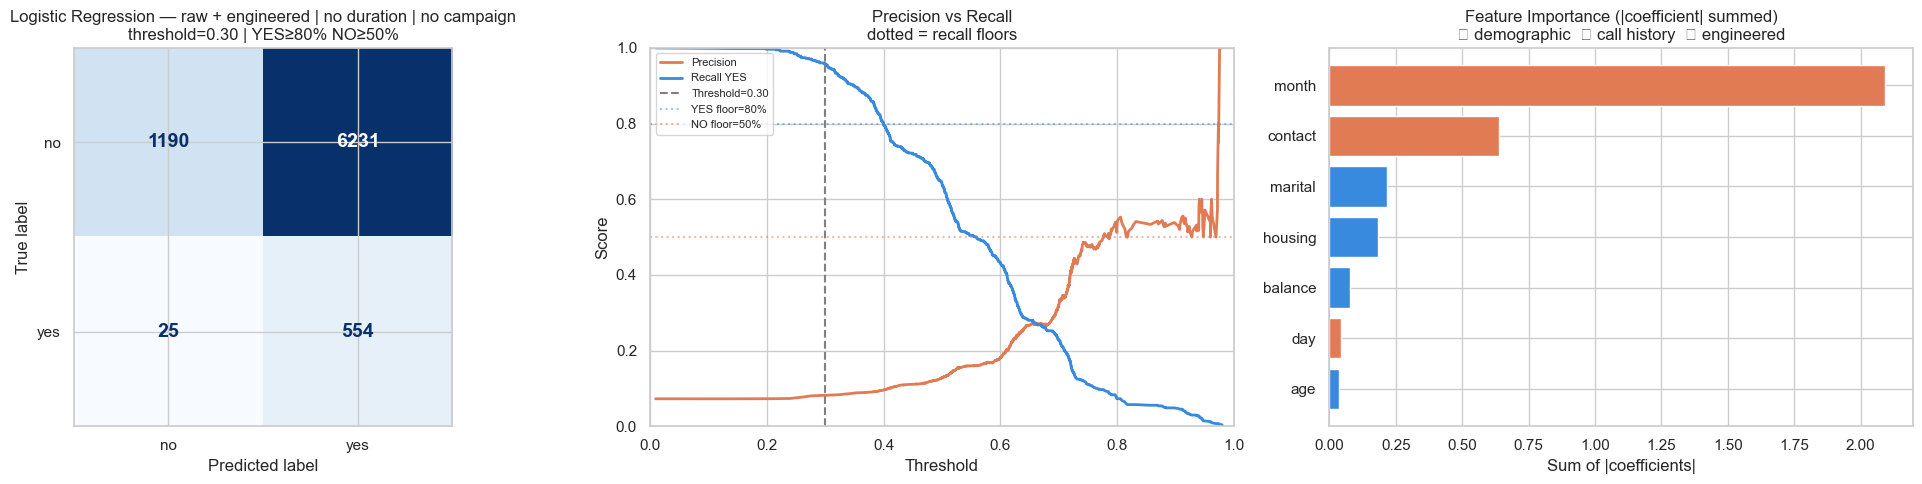

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                             confusion_matrix, precision_recall_curve,
                             roc_auc_score)

# ════════════════════════════════════════════════════════════════════
# FEATURE LIST
# ════════════════════════════════════════════════════════════════════

ALL_FEATURES = [
   'day', 'month', 'contact', 'age', 'marital',
    'balance','housing'
]

ACTIVE_SET = "raw + engineered | no duration | no campaign"

# ── dual recall targets ───────────────────────────────────────────────
YES_RECALL_FLOOR = 0.80
NO_RECALL_FLOOR  = 0.50

# ── colour coding ─────────────────────────────────────────────────────
DEMO_COLS = ['age', 'job', 'marital', 'education',
             'default', 'balance', 'housing', 'loan']
CALL_COLS = ['contact', 'day', 'month', 'duration', 'campaign']

print("=" * 65)
print("   Logistic Regression — DUAL RECALL THRESHOLD TUNING")
print(f"   Active set       : {ACTIVE_SET}")
print(f"   YES recall floor : {YES_RECALL_FLOOR*100:.0f}%")
print(f"   NO  recall floor : {NO_RECALL_FLOOR*100:.0f}%")
print("=" * 65)
print(f"\nFeatures in use ({len(ALL_FEATURES)}) : {ALL_FEATURES}")

# ── prepare data ──────────────────────────────────────────────────────
model_df          = eda_df.copy()
model_df['y_enc'] = (model_df['y'] == 'yes').astype(int)

# ── categorical and numeric split ────────────────────────────────────
CAT_COLS = ['job', 'marital', 'education', 'default',
            'housing', 'loan', 'contact', 'month', 'age_group']
CAT_COLS = [c for c in CAT_COLS if c in ALL_FEATURES]
NUM_COLS = [c for c in ALL_FEATURES if c not in CAT_COLS]

print(f"\nCategorical cols ({len(CAT_COLS)}) : {CAT_COLS}")
print(f"Numeric cols    ({len(NUM_COLS)}) : {NUM_COLS}")

# force str on categoricals before get_dummies
for col in CAT_COLS:
    model_df[col] = model_df[col].astype(str)

# one-hot encode — LR needs proper dummy coding for nominal features
model_enc = pd.get_dummies(model_df[ALL_FEATURES + ['y_enc']],
                           columns=CAT_COLS,
                           drop_first=True)   # drop_first=True avoids multicollinearity

FINAL_FEATURES = [c for c in model_enc.columns if c != 'y_enc']
print(f"\nFeatures after one-hot encoding : {len(FINAL_FEATURES)}")

# ── X / y ─────────────────────────────────────────────────────────────
X = model_enc[FINAL_FEATURES].values.astype(np.float32)
y = model_enc['y_enc'].values

# ── train / test split ────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTrain : {X_train.shape[0]} rows "
      f"(yes: {y_train.sum()}, no: {(y_train==0).sum()})")
print(f"Test  : {X_test.shape[0]} rows "
      f"(yes: {y_test.sum()},  no: {(y_test==0).sum()})")

# ── scale all features — critical for LR ─────────────────────────────
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# ── train Logistic Regression ─────────────────────────────────────────
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
print(f"\nClass weight : 'balanced'  (no={neg_count}, yes={pos_count})")

lr = LogisticRegression(
    C=0.1,                    # regularisation (smaller = stronger)
    class_weight='balanced',  # handles imbalance
    solver='lbfgs',
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)
lr.fit(X_train, y_train)
print("Model trained ✓")
print(f"ROC-AUC : {roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]):.4f}")

# ── dual recall threshold search ─────────────────────────────────────
y_prob = lr.predict_proba(X_test)[:, 1]
precision_arr, recall_arr, thresholds_arr = precision_recall_curve(
    y_test, y_prob)

best_threshold = 0.3
best_yes_f1    = 0
threshold_log  = []

for thresh in np.arange(0.05, 0.80, 0.01):
    preds = (y_prob >= thresh).astype(int)
    cm_t  = confusion_matrix(y_test, preds)
    if cm_t.shape == (2, 2):
        tn_t, fp_t, fn_t, tp_t = cm_t.ravel()

        yes_rec  = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
        no_rec   = tn_t / (tn_t + fp_t) if (tn_t + fp_t) > 0 else 0
        yes_prec = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
        yes_f1   = (2 * yes_prec * yes_rec /
                    (yes_prec + yes_rec)
                    if (yes_prec + yes_rec) > 0 else 0)

        threshold_log.append({
            'threshold': round(thresh, 2),
            'yes_recall': round(yes_rec  * 100, 1),
            'no_recall' : round(no_rec   * 100, 1),
            'yes_prec'  : round(yes_prec * 100, 1),
            'yes_f1'    : round(yes_f1   * 100, 1),
            'fn'        : fn_t,
            'fp'        : fp_t,
            'valid'     : (yes_rec >= YES_RECALL_FLOOR
                           and no_rec >= NO_RECALL_FLOOR)
        })

        if (yes_rec >= YES_RECALL_FLOOR
                and no_rec >= NO_RECALL_FLOOR
                and yes_f1 > best_yes_f1):
            best_yes_f1    = yes_f1
            best_threshold = thresh

# ── threshold scan table ──────────────────────────────────────────────
print("\n" + "=" * 78)
print("   THRESHOLD SCAN — YES recall vs NO recall trade-off")
print(f"   ✅ = meets both floors "
      f"(YES≥{YES_RECALL_FLOOR*100:.0f}% AND NO≥{NO_RECALL_FLOOR*100:.0f}%)")
print("=" * 78)
print(f"  {'Thresh':>7} {'YES rec':>8} {'NO rec':>8} "
      f"{'YES prec':>9} {'YES F1':>8} {'FN':>5} {'FP':>6}")
print("-" * 78)

for row in threshold_log:
    tag = '✅' if row['valid'] else '  '
    print(f"  {tag} {row['threshold']:>5.2f}   "
          f"{row['yes_recall']:>6.1f}%  "
          f"{row['no_recall']:>6.1f}%  "
          f"{row['yes_prec']:>7.1f}%  "
          f"{row['yes_f1']:>6.1f}%  "
          f"{row['fn']:>4}  {row['fp']:>5}")

print("=" * 78)
print(f"\n  Auto-selected threshold : {best_threshold:.2f}")
print(f"  Reasoning : best YES F1 while "
      f"YES≥{YES_RECALL_FLOOR*100:.0f}% AND NO≥{NO_RECALL_FLOOR*100:.0f}%")

THRESHOLD    = best_threshold
y_pred_tuned = (y_prob >= THRESHOLD).astype(int)

# ── classification report ─────────────────────────────────────────────
print(f"\nClassification Report (threshold = {THRESHOLD:.2f}):")
print(classification_report(y_test, y_pred_tuned,
      target_names=['no', 'yes']))

# ── confusion matrix breakdown ────────────────────────────────────────
cm             = confusion_matrix(y_test, y_pred_tuned)
tn, fp, fn, tp = cm.ravel()

no_precision  = tn / (tn + fn)  if (tn + fn)  > 0 else 0
no_recall     = tn / (tn + fp)  if (tn + fp)  > 0 else 0
no_f1         = (2 * no_precision * no_recall /
                 (no_precision + no_recall)
                 if (no_precision + no_recall) > 0 else 0)
yes_precision = tp / (tp + fp)  if (tp + fp)  > 0 else 0
yes_recall    = tp / (tp + fn)  if (tp + fn)  > 0 else 0
yes_f1        = (2 * yes_precision * yes_recall /
                 (yes_precision + yes_recall)
                 if (yes_precision + yes_recall) > 0 else 0)
accuracy      = (tn + tp) / (tn + fp + fn + tp)

print("=" * 60)
print("            CONFUSION MATRIX BREAKDOWN")
print("=" * 60)
print(f"  True  Negative (TN) : {tn:>6}  — correctly predicted NO")
print(f"  False Positive (FP) : {fp:>6}  — said YES but actually NO")
print(f"  False Negative (FN) : {fn:>6}  — said NO but actually YES  ← minimise")
print(f"  True  Positive (TP) : {tp:>6}  — correctly predicted YES")
print("=" * 60)
print(f"  Overall Accuracy    : {accuracy*100:.1f}%")
print("=" * 60)
print("\n" + "=" * 60)
print("       FULL CLASSIFICATION REPORT BY CLASS")
print("=" * 60)
print(f"  {'Metric':<18} {'NO (class 0)':>15} {'YES (class 1)':>15}")
print("-" * 60)
print(f"  {'Precision':<18} {no_precision*100:>14.1f}% {yes_precision*100:>14.1f}%")
print(f"  {'Recall':<18} {no_recall*100:>14.1f}% {yes_recall*100:>14.1f}%")
print(f"  {'F1 Score':<18} {no_f1*100:>14.1f}% {yes_f1*100:>14.1f}%")
print(f"  {'Support':<18} {tn+fp:>15} {tp+fn:>15}")
print("=" * 60)
print(f"\n  ► YES recall floor set : {YES_RECALL_FLOOR*100:.0f}%")
print(f"  ► NO  recall floor set : {NO_RECALL_FLOOR*100:.0f}%")
print(f"  ► Recall YES achieved  : {yes_recall*100:.1f}%")
print(f"  ► Recall NO  achieved  : {no_recall*100:.1f}%")
print(f"  ► FN (missed yes)      : {fn}")
print(f"  ► FP (noise)           : {fp}")
print("=" * 60)

# ── feature importance via coefficients ──────────────────────────────
# aggregate one-hot dummies back to original feature name
coef_series = pd.Series(np.abs(lr.coef_[0]), index=FINAL_FEATURES)

imp_dict = {}
for orig_feat in ALL_FEATURES:
    idxs = [c for c in FINAL_FEATURES
            if c == orig_feat or c.startswith(f"{orig_feat}_")]
    if idxs:
        imp_dict[orig_feat] = coef_series[idxs].sum()
    else:
        imp_dict[orig_feat] = 0.0

imp_df = pd.DataFrame.from_dict(
    imp_dict, orient='index', columns=['importance']
).sort_values('importance', ascending=True)

# ── plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1 — confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tuned,
    display_labels=['no', 'yes'],
    cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title(f'Logistic Regression — {ACTIVE_SET}\n'
                  f'threshold={THRESHOLD:.2f} | '
                  f'YES≥{YES_RECALL_FLOOR*100:.0f}% '
                  f'NO≥{NO_RECALL_FLOOR*100:.0f}%')
for text in axes[0].texts:
    text.set_fontsize(14)
    text.set_fontweight('bold')

# 2 — precision recall curve
axes[1].plot(thresholds_arr, precision_arr[:-1],
             label='Precision', color='#e07b54', linewidth=2)
axes[1].plot(thresholds_arr, recall_arr[:-1],
             label='Recall YES', color='#378add', linewidth=2)
axes[1].axvline(x=THRESHOLD, color='gray', linestyle='--',
                label=f'Threshold={THRESHOLD:.2f}')
axes[1].axhline(y=YES_RECALL_FLOOR, color='#378add',
                linestyle=':', alpha=0.5,
                label=f'YES floor={YES_RECALL_FLOOR*100:.0f}%')
axes[1].axhline(y=NO_RECALL_FLOOR, color='#e07b54',
                linestyle=':', alpha=0.5,
                label=f'NO floor={NO_RECALL_FLOOR*100:.0f}%')
axes[1].set_title('Precision vs Recall\ndotted = recall floors')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].legend(fontsize=8)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

# 3 — coefficient-based feature importance
colors = ['#378add' if f in DEMO_COLS
          else '#e07b54' if f in CALL_COLS
          else '#2ecc71'
          for f in imp_df.index]

axes[2].barh(imp_df.index, imp_df['importance'],
             color=colors, edgecolor='white')
axes[2].set_title('Feature Importance (|coefficient| summed)\n'
                  '🔵 demographic  🟠 call history  🟢 engineered')
axes[2].set_xlabel('Sum of |coefficients|')

plt.tight_layout()
plt.show()

   FULL-DATA SCORING  —  Logistic Regression
   Data : data/term-deposit-marketing-2020.csv
   Threshold : 0.30  (same as test-set tuning)

  Full dataset loaded : 40,000 rows
    TRUE yes : 2,896 (7.2%)
    TRUE no  : 37,104 (92.8%)

  Encoded shape : (40000, 18)  (columns aligned to training : 18)

   FULL-DATA RESULTS  (threshold = 0.30)
  TN =   5705  FP =  31399
  FN =    161  TP =   2735

  YES recall    : 94.4%
  NO  recall    : 15.4%
  YES precision : 8.0%
  Accuracy      : 21.1%

  Flagged for calling : 34,134  (85.3% of all 40,000 clients)
    → True  YES in pool : 2,735  (8.0% conversion rate)
    → False pos (noise) : 31,399
  Eliminated (pred NO) : 5,866
    → True  NO saved    : 5,705  (no wasted call)
    → Missed YES (FN)   : 161  (sacrifice)

   TEST SET  vs  FULL DATA  —  sanity check
  Metric                     Test 20%    Full 100%
  ----------------------------------------------
  YES recall                    91.9%        94.4%
  NO recall                     26.

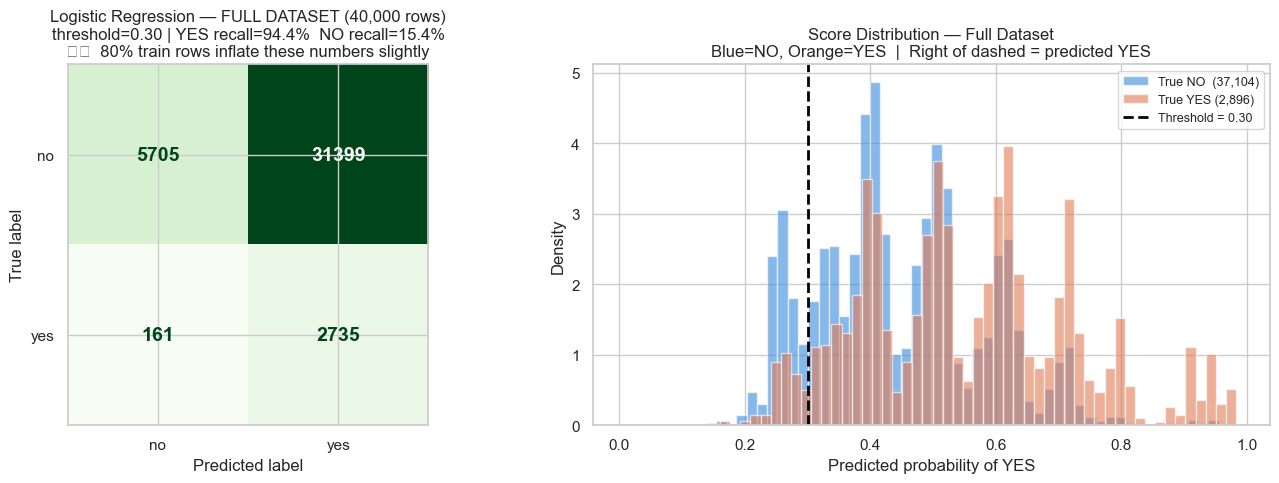

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ════════════════════════════════════════════════════════════════════
# FULL-DATA SCORING  —  Logistic Regression (already trained above)
#
# The lr model, scaler, FINAL_FEATURES, and THRESHOLD are all already
# in memory from running the training cell. This cell just loads the
# full dataset, applies the exact same preprocessing, and scores
# every single row.
#
# ⚠️  IMPORTANT: run the training cell first so these exist:
#     lr, scaler, FINAL_FEATURES, THRESHOLD, CAT_COLS, ALL_FEATURES
# ════════════════════════════════════════════════════════════════════

DATA_PATH = 'data/term-deposit-marketing-2020.csv'

print("=" * 65)
print("   FULL-DATA SCORING  —  Logistic Regression")
print(f"   Data : {DATA_PATH}")
print(f"   Threshold : {THRESHOLD:.2f}  (same as test-set tuning)")
print("=" * 65)

# ── load full dataset ─────────────────────────────────────────────────
full_df          = pd.read_csv(DATA_PATH)
full_df['y_enc'] = (full_df['y'] == 'yes').astype(int)

print(f"\n  Full dataset loaded : {len(full_df):,} rows")
print(f"    TRUE yes : {full_df['y_enc'].sum():,} "
      f"({full_df['y_enc'].mean()*100:.1f}%)")
print(f"    TRUE no  : {(full_df['y_enc']==0).sum():,} "
      f"({(full_df['y_enc']==0).mean()*100:.1f}%)")

# ── apply IDENTICAL preprocessing ────────────────────────────────────
# Step 1: force cat cols to string (same as training)
for col in CAT_COLS:
    if col in full_df.columns:
        full_df[col] = full_df[col].astype(str)

# Step 2: one-hot encode with same settings
full_enc = pd.get_dummies(full_df[ALL_FEATURES], columns=CAT_COLS, drop_first=True)

# Step 3: align columns to FINAL_FEATURES used during training
# — adds any missing dummies as 0, drops any extras
full_enc = full_enc.reindex(columns=FINAL_FEATURES, fill_value=0)

# Step 4: scale using the SAME scaler fitted on train data
X_full = scaler.transform(full_enc.values.astype(np.float32))
y_full = full_df['y_enc'].values

print(f"\n  Encoded shape : {X_full.shape}  "
      f"(columns aligned to training : {len(FINAL_FEATURES)})")

# ── score every row ───────────────────────────────────────────────────
y_prob_full = lr.predict_proba(X_full)[:, 1]
y_pred_full = (y_prob_full >= THRESHOLD).astype(int)

# ── results ───────────────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix, classification_report

cm_full             = confusion_matrix(y_full, y_pred_full)
tn, fp, fn, tp      = cm_full.ravel()
yes_recall_full     = tp / (tp + fn)
no_recall_full      = tn / (tn + fp)
yes_precision_full  = tp / (tp + fp) if (tp + fp) > 0 else 0
accuracy_full       = (tn + tp) / len(y_full)

print("\n" + "=" * 65)
print(f"   FULL-DATA RESULTS  (threshold = {THRESHOLD:.2f})")
print("=" * 65)
print(f"  TN = {tn:>6}  FP = {fp:>6}")
print(f"  FN = {fn:>6}  TP = {tp:>6}")
print()
print(f"  YES recall    : {yes_recall_full*100:.1f}%")
print(f"  NO  recall    : {no_recall_full*100:.1f}%")
print(f"  YES precision : {yes_precision_full*100:.1f}%")
print(f"  Accuracy      : {accuracy_full*100:.1f}%")
print()
print(f"  Flagged for calling : {tp + fp:,}  "
      f"({(tp+fp)/len(y_full)*100:.1f}% of all {len(y_full):,} clients)")
print(f"    → True  YES in pool : {tp:,}  "
      f"({tp/(tp+fp)*100:.1f}% conversion rate)")
print(f"    → False pos (noise) : {fp:,}")
print(f"  Eliminated (pred NO) : {tn + fn:,}")
print(f"    → True  NO saved    : {tn:,}  (no wasted call)")
print(f"    → Missed YES (FN)   : {fn:,}  (sacrifice)")
print("=" * 65)

# ── compare test-set vs full-data ─────────────────────────────────────
print("\n" + "=" * 65)
print("   TEST SET  vs  FULL DATA  —  sanity check")
print("=" * 65)
print(f"  {'Metric':<22} {'Test 20%':>12} {'Full 100%':>12}")
print(f"  {'-'*46}")
print(f"  {'YES recall':<22} {yes_recall*100:>11.1f}% {yes_recall_full*100:>11.1f}%")
print(f"  {'NO recall':<22} {no_recall*100:>11.1f}% {no_recall_full*100:>11.1f}%")
print(f"  {'YES precision':<22} {yes_precision*100:>11.1f}% {yes_precision_full*100:>11.1f}%")
print(f"  {'Flagged (TP+FP)':<22} {tp_test+fp_test:>12,} {tp+fp:>12,}"
      if 'tp_test' in dir() else
      f"  {'Flagged (TP+FP)':<22} {'(see above)':>12} {tp+fp:>12,}")
print("=" * 65)
print()
print("  ℹ️   Full-data numbers will look slightly better on the 80%")
print("      training rows — the model has seen those before.")
print("      The 20% test numbers are the honest benchmark.")

# ── export predicted-YES pool ─────────────────────────────────────────
pos_mask        = y_pred_full == 1
export_full_df  = full_df[pos_mask].copy()
export_full_df['lr_prob']   = y_prob_full[pos_mask]
export_full_df['predicted'] = 'YES'

EXPORT_PATH = 'full_data_predicted_yes.csv'
export_full_df.to_csv(EXPORT_PATH, index=False)

print(f"\n  ✅  Predicted-YES pool saved → {EXPORT_PATH}")
print(f"      Rows    : {len(export_full_df):,}")
print(f"      Columns : {list(export_full_df.columns)}")

# ── plot ──────────────────────────────────────────────────────────────
from sklearn.metrics import ConfusionMatrixDisplay, precision_recall_curve

precision_full, recall_full, thresh_full = precision_recall_curve(y_full, y_prob_full)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1 — confusion matrix (full data)
ConfusionMatrixDisplay.from_predictions(
    y_full, y_pred_full,
    display_labels=['no', 'yes'],
    cmap='Greens', ax=axes[0], colorbar=False)
axes[0].set_title(
    f'Logistic Regression — FULL DATASET ({len(y_full):,} rows)\n'
    f'threshold={THRESHOLD:.2f} | '
    f'YES recall={yes_recall_full*100:.1f}%  '
    f'NO recall={no_recall_full*100:.1f}%\n'
    f'⚠️  80% train rows inflate these numbers slightly')
for t in axes[0].texts:
    t.set_fontsize(14); t.set_fontweight('bold')

# 2 — probability distribution of full data
axes[1].hist(y_prob_full[y_full == 0], bins=60, alpha=0.6,
             color='#378add', label=f'True NO  ({(y_full==0).sum():,})', density=True)
axes[1].hist(y_prob_full[y_full == 1], bins=60, alpha=0.6,
             color='#e07b54', label=f'True YES ({y_full.sum():,})', density=True)
axes[1].axvline(x=THRESHOLD, color='black', linestyle='--', linewidth=2,
                label=f'Threshold = {THRESHOLD:.2f}')
axes[1].set_title('Score Distribution — Full Dataset\n'
                  'Blue=NO, Orange=YES  |  Right of dashed = predicted YES')
axes[1].set_xlabel('Predicted probability of YES')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

   STACKING — Random Forest + XGBoost → Logistic Regression
   Features         : 7 (same as both base models)
   YES recall floor : 80%
   NO  recall floor : 50%

Features : ['day', 'month', 'contact', 'age', 'marital', 'balance', 'housing']

Train : 32000 rows  (yes=2317, no=29683)
Test  : 8000 rows  (yes=579, no=7421)
scale_pos_weight for XGB : 12.81

── Generating 5-fold OOF predictions ──
  Fold 1 done
  Fold 2 done
  Fold 3 done
  Fold 4 done
  Fold 5 done
OOF predictions complete ✓

  OOF AUC — RF  : 0.6971
  OOF AUC — XGB : 0.7015

── Complementarity check (on OOF) ──
  RF false positives (wrong NO predictions) : 17399
  Of those, XGB says NO (XGB corrects RF)   : 1660  (9.5%)
  Of those, XGB also says YES (both wrong)  : 15739  (90.5%)
  → Higher 'XGB corrects RF' % = more complementary = better stack

── Training final base models on full train set ──
Base models trained ✓

  Test AUC — RF  : 0.7142
  Test AUC — XGB : 0.7188

── Meta-learner (Logistic Regression) ──
  Coeffic

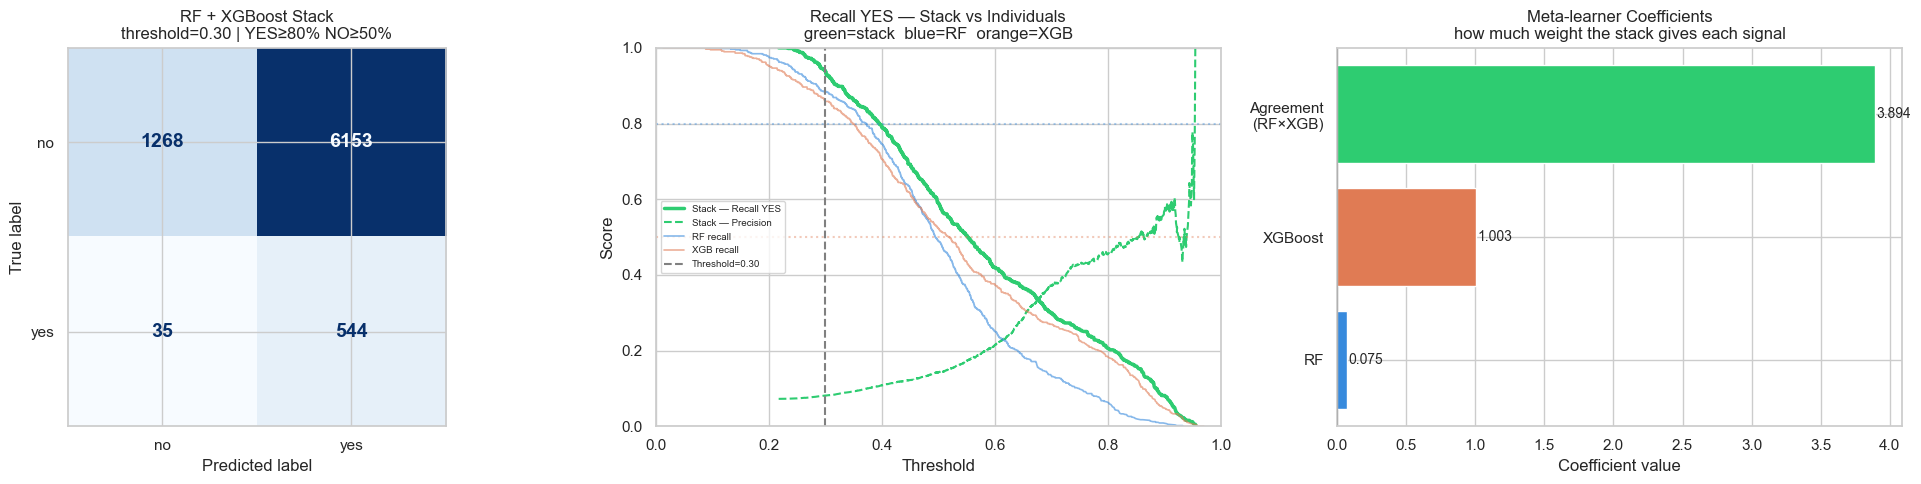

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                             confusion_matrix, precision_recall_curve,
                             roc_auc_score)
from xgboost import XGBClassifier

# ════════════════════════════════════════════════════════════════════
# FEATURE LIST — same as both individual models
# ════════════════════════════════════════════════════════════════════

ALL_FEATURES = [
    'day', 'month', 'contact', 'age', 'marital',
    'balance', 'housing'
]

ACTIVE_SET = "RF + XGBoost stack | same 10 features"

YES_RECALL_FLOOR = 0.80
NO_RECALL_FLOOR  = 0.50

DEMO_COLS = ['age', 'job', 'marital', 'education',
             'default', 'balance', 'housing', 'loan']
CALL_COLS = ['contact', 'day', 'month', 'duration', 'campaign']

print("=" * 65)
print("   STACKING — Random Forest + XGBoost → Logistic Regression")
print(f"   Features         : {len(ALL_FEATURES)} (same as both base models)")
print(f"   YES recall floor : {YES_RECALL_FLOOR*100:.0f}%")
print(f"   NO  recall floor : {NO_RECALL_FLOOR*100:.0f}%")
print("=" * 65)
print(f"\nFeatures : {ALL_FEATURES}")

# ── prepare data ──────────────────────────────────────────────────────
model_df          = eda_df.copy()
model_df['y_enc'] = (model_df['y'] == 'yes').astype(int)

le = LabelEncoder()
for col in ALL_FEATURES:
    if (model_df[col].dtype == 'object'
            or model_df[col].dtype.name in ('str', 'category')):
        model_df[col] = le.fit_transform(model_df[col].astype(str))

X = model_df[ALL_FEATURES].values
y = model_df['y_enc'].values

# ── train / test split ────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

neg_count   = (y_train == 0).sum()
pos_count   = (y_train == 1).sum()
scale_pos_w = neg_count / pos_count

print(f"\nTrain : {X_train.shape[0]} rows  "
      f"(yes={y_train.sum()}, no={(y_train==0).sum()})")
print(f"Test  : {X_test.shape[0]} rows  "
      f"(yes={y_test.sum()}, no={(y_test==0).sum()})")
print(f"scale_pos_weight for XGB : {scale_pos_w:.2f}")

# ════════════════════════════════════════════════════════════════════
# STEP 1 — generate out-of-fold (OOF) predictions for meta-learner
# ════════════════════════════════════════════════════════════════════
# Why OOF: if we train RF/XGB on full X_train and then use their
# predictions as meta-features on the same X_train, the meta-learner
# sees memorised predictions and overfits.
# OOF = each fold's model is trained on the other folds, so the
# predictions on the held-out fold are honest (never seen during fit).

N_FOLDS = 5
skf     = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_rf  = np.zeros(len(X_train))   # RF prob for YES on each train row
oof_xgb = np.zeros(len(X_train))   # XGB prob for YES on each train row

print(f"\n── Generating {N_FOLDS}-fold OOF predictions ──")

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    Xtr, Xval = X_train[tr_idx], X_train[val_idx]
    ytr, yval = y_train[tr_idx], y_train[val_idx]

    # ── RF ──
    rf_fold = RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=5,
        max_features='sqrt', class_weight='balanced',
        random_state=42, n_jobs=-1)
    rf_fold.fit(Xtr, ytr)
    oof_rf[val_idx] = rf_fold.predict_proba(Xval)[:, 1]

    # ── XGB ──
    neg_f = (ytr == 0).sum()
    pos_f = (ytr == 1).sum()
    xgb_fold = XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        scale_pos_weight=neg_f / pos_f,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='aucpr', random_state=42,
        n_jobs=-1, verbosity=0)
    xgb_fold.fit(Xtr, ytr)
    oof_xgb[val_idx] = xgb_fold.predict_proba(Xval)[:, 1]

    print(f"  Fold {fold} done")

print("OOF predictions complete ✓")

# ── OOF AUC check ─────────────────────────────────────────────────────
print(f"\n  OOF AUC — RF  : {roc_auc_score(y_train, oof_rf):.4f}")
print(f"  OOF AUC — XGB : {roc_auc_score(y_train, oof_xgb):.4f}")

# ── error agreement check — how complementary are the models? ─────────
# use 0.35 for RF (its best threshold) and 0.30 for XGB (its best)
rf_oof_pred  = (oof_rf  >= 0.35).astype(int)
xgb_oof_pred = (oof_xgb >= 0.30).astype(int)

fp_mask   = (y_train == 0) & (rf_oof_pred == 1)   # RF's false positives
xgb_on_fp = xgb_oof_pred[fp_mask]

print(f"\n── Complementarity check (on OOF) ──")
print(f"  RF false positives (wrong NO predictions) : {fp_mask.sum()}")
print(f"  Of those, XGB says NO (XGB corrects RF)   : {(xgb_on_fp==0).sum()}  "
      f"({(xgb_on_fp==0).sum()/fp_mask.sum()*100:.1f}%)")
print(f"  Of those, XGB also says YES (both wrong)  : {(xgb_on_fp==1).sum()}  "
      f"({(xgb_on_fp==1).sum()/fp_mask.sum()*100:.1f}%)")
print("  → Higher 'XGB corrects RF' % = more complementary = better stack")

# ════════════════════════════════════════════════════════════════════
# STEP 2 — train final base models on full X_train
# ════════════════════════════════════════════════════════════════════

print("\n── Training final base models on full train set ──")

rf_final = RandomForestClassifier(
    n_estimators=300, max_depth=10, min_samples_leaf=5,
    max_features='sqrt', class_weight='balanced',
    random_state=42, n_jobs=-1)
rf_final.fit(X_train, y_train)

xgb_final = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=5,
    scale_pos_weight=scale_pos_w,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='aucpr', random_state=42,
    n_jobs=-1, verbosity=0)
xgb_final.fit(X_train, y_train)

print("Base models trained ✓")

# ── test set predictions from base models ────────────────────────────
test_rf  = rf_final.predict_proba(X_test)[:, 1]
test_xgb = xgb_final.predict_proba(X_test)[:, 1]

print(f"\n  Test AUC — RF  : {roc_auc_score(y_test, test_rf):.4f}")
print(f"  Test AUC — XGB : {roc_auc_score(y_test, test_xgb):.4f}")

# ════════════════════════════════════════════════════════════════════
# STEP 3 — train meta-learner on OOF predictions
# ════════════════════════════════════════════════════════════════════
# Meta-features: [rf_prob, xgb_prob, rf_prob * xgb_prob (agreement term)]

meta_train = np.column_stack([oof_rf, oof_xgb, oof_rf * oof_xgb])
meta_test  = np.column_stack([test_rf, test_xgb, test_rf * test_xgb])

meta_lr = LogisticRegression(
    C=1.0,
    class_weight='balanced',
    random_state=42,
    max_iter=1000)
meta_lr.fit(meta_train, y_train)

print("\n── Meta-learner (Logistic Regression) ──")
print(f"  Coefficients : RF={meta_lr.coef_[0][0]:.3f}  "
      f"XGB={meta_lr.coef_[0][1]:.3f}  "
      f"Agreement={meta_lr.coef_[0][2]:.3f}")
print("  (larger coef = model trusted more by meta-learner)")

y_prob_stack = meta_lr.predict_proba(meta_test)[:, 1]
print(f"\n  Stack AUC : {roc_auc_score(y_test, y_prob_stack):.4f}")

# ════════════════════════════════════════════════════════════════════
# STEP 4 — threshold scan on stacked probabilities
# ════════════════════════════════════════════════════════════════════

precision_arr, recall_arr, thresholds_arr = precision_recall_curve(
    y_test, y_prob_stack)

best_threshold = 0.3
best_yes_f1    = 0
threshold_log  = []

for thresh in np.arange(0.05, 0.80, 0.01):
    preds = (y_prob_stack >= thresh).astype(int)
    cm_t  = confusion_matrix(y_test, preds)
    if cm_t.shape == (2, 2):
        tn_t, fp_t, fn_t, tp_t = cm_t.ravel()

        yes_rec  = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
        no_rec   = tn_t / (tn_t + fp_t) if (tn_t + fp_t) > 0 else 0
        yes_prec = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
        yes_f1   = (2 * yes_prec * yes_rec /
                    (yes_prec + yes_rec)
                    if (yes_prec + yes_rec) > 0 else 0)

        threshold_log.append({
            'threshold': round(thresh, 2),
            'yes_recall': round(yes_rec  * 100, 1),
            'no_recall' : round(no_rec   * 100, 1),
            'yes_prec'  : round(yes_prec * 100, 1),
            'yes_f1'    : round(yes_f1   * 100, 1),
            'fn'        : fn_t,
            'fp'        : fp_t,
            'valid'     : (yes_rec >= YES_RECALL_FLOOR
                           and no_rec >= NO_RECALL_FLOOR)
        })

        if (yes_rec >= YES_RECALL_FLOOR
                and no_rec >= NO_RECALL_FLOOR
                and yes_f1 > best_yes_f1):
            best_yes_f1    = yes_f1
            best_threshold = thresh

# ── threshold scan table ──────────────────────────────────────────────
print("\n" + "=" * 78)
print("   THRESHOLD SCAN — YES recall vs NO recall trade-off")
print(f"   ✅ = meets both floors "
      f"(YES≥{YES_RECALL_FLOOR*100:.0f}% AND NO≥{NO_RECALL_FLOOR*100:.0f}%)")
print("=" * 78)
print(f"  {'Thresh':>7} {'YES rec':>8} {'NO rec':>8} "
      f"{'YES prec':>9} {'YES F1':>8} {'FN':>5} {'FP':>6}")
print("-" * 78)

for row in threshold_log:
    tag = '✅' if row['valid'] else '  '
    print(f"  {tag} {row['threshold']:>5.2f}   "
          f"{row['yes_recall']:>6.1f}%  "
          f"{row['no_recall']:>6.1f}%  "
          f"{row['yes_prec']:>7.1f}%  "
          f"{row['yes_f1']:>6.1f}%  "
          f"{row['fn']:>4}  {row['fp']:>5}")

print("=" * 78)
print(f"\n  Auto-selected threshold : {best_threshold:.2f}")

THRESHOLD    = best_threshold
y_pred_tuned = (y_prob_stack >= THRESHOLD).astype(int)

# ── results ───────────────────────────────────────────────────────────
cm             = confusion_matrix(y_test, y_pred_tuned)
tn, fp, fn, tp = cm.ravel()

no_recall     = tn / (tn + fp)  if (tn + fp)  > 0 else 0
yes_recall    = tp / (tp + fn)  if (tp + fn)  > 0 else 0
no_precision  = tn / (tn + fn)  if (tn + fn)  > 0 else 0
yes_precision = tp / (tp + fp)  if (tp + fp)  > 0 else 0
no_f1         = (2 * no_precision * no_recall /
                 (no_precision + no_recall) if (no_precision + no_recall) > 0 else 0)
yes_f1        = (2 * yes_precision * yes_recall /
                 (yes_precision + yes_recall) if (yes_precision + yes_recall) > 0 else 0)
accuracy      = (tn + tp) / (tn + fp + fn + tp)

print(f"\nClassification Report (threshold = {THRESHOLD:.2f}):")
print(classification_report(y_test, y_pred_tuned, target_names=['no', 'yes']))

print("=" * 60)
print("            CONFUSION MATRIX BREAKDOWN")
print("=" * 60)
print(f"  True  Negative (TN) : {tn:>6}  — correctly predicted NO")
print(f"  False Positive (FP) : {fp:>6}  — said YES but actually NO")
print(f"  False Negative (FN) : {fn:>6}  — said NO but actually YES  ← minimise")
print(f"  True  Positive (TP) : {tp:>6}  — correctly predicted YES")
print("=" * 60)
print(f"  Overall Accuracy    : {accuracy*100:.1f}%")
print("=" * 60)
print(f"\n  ► YES recall achieved  : {yes_recall*100:.1f}%  "
      f"(floor {YES_RECALL_FLOOR*100:.0f}%)")
print(f"  ► NO  recall achieved  : {no_recall*100:.1f}%  "
      f"(floor {NO_RECALL_FLOOR*100:.0f}%)")
print(f"  ► FN (missed yes)      : {fn}")
print(f"  ► FP (noise)           : {fp}")

# ── comparison table vs individual models ────────────────────────────
print("\n" + "=" * 60)
print("   STACK vs INDIVIDUAL MODELS (at their best threshold)")
print("=" * 60)
print(f"  {'Model':<20} {'YES rec':>8} {'NO rec':>8} {'FN':>6} {'FP':>7}")
print("-" * 60)

# RF at 0.35
rf_pred = (test_rf >= 0.35).astype(int)
cm_rf   = confusion_matrix(y_test, rf_pred).ravel()
tn_r, fp_r, fn_r, tp_r = cm_rf
print(f"  {'RF (0.35)':<20} "
      f"{tp_r/(tp_r+fn_r)*100:>7.1f}%"
      f"{tn_r/(tn_r+fp_r)*100:>8.1f}%"
      f"{fn_r:>7}{fp_r:>8}")

# XGB at 0.30
xgb_pred = (test_xgb >= 0.30).astype(int)
cm_xgb   = confusion_matrix(y_test, xgb_pred).ravel()
tn_x, fp_x, fn_x, tp_x = cm_xgb
print(f"  {'XGB (0.30)':<20} "
      f"{tp_x/(tp_x+fn_x)*100:>7.1f}%"
      f"{tn_x/(tn_x+fp_x)*100:>8.1f}%"
      f"{fn_x:>7}{fp_x:>8}")

# Stack
print(f"  {'Stack ({:.2f})'.format(THRESHOLD):<20} "
      f"{yes_recall*100:>7.1f}%"
      f"{no_recall*100:>8.1f}%"
      f"{fn:>7}{fp:>8}")
print("=" * 60)

# ── plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1 — confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tuned,
    display_labels=['no', 'yes'],
    cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title(f'RF + XGBoost Stack\n'
                  f'threshold={THRESHOLD:.2f} | '
                  f'YES≥{YES_RECALL_FLOOR*100:.0f}% '
                  f'NO≥{NO_RECALL_FLOOR*100:.0f}%')
for text in axes[0].texts:
    text.set_fontsize(14)
    text.set_fontweight('bold')

# 2 — precision recall curve (stack vs individuals)
axes[1].plot(thresholds_arr, recall_arr[:-1],
             label='Stack — Recall YES', color='#2ecc71', linewidth=2.5)
axes[1].plot(thresholds_arr, precision_arr[:-1],
             label='Stack — Precision', color='#2ecc71',
             linewidth=1.5, linestyle='--')

# overlay individual model curves
prec_rf, rec_rf, thr_rf = precision_recall_curve(y_test, test_rf)
prec_xgb, rec_xgb, thr_xgb = precision_recall_curve(y_test, test_xgb)

axes[1].plot(thr_rf,  rec_rf[:-1],  label='RF recall',  color='#378add',
             linewidth=1.2, alpha=0.6)
axes[1].plot(thr_xgb, rec_xgb[:-1], label='XGB recall', color='#e07b54',
             linewidth=1.2, alpha=0.6)

axes[1].axvline(x=THRESHOLD, color='gray', linestyle='--',
                label=f'Threshold={THRESHOLD:.2f}')
axes[1].axhline(y=YES_RECALL_FLOOR, color='#378add', linestyle=':', alpha=0.4)
axes[1].axhline(y=NO_RECALL_FLOOR,  color='#e07b54', linestyle=':', alpha=0.4)
axes[1].set_title('Recall YES — Stack vs Individuals\n'
                  'green=stack  blue=RF  orange=XGB')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].legend(fontsize=7)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

# 3 — meta-learner weights + base model AUCs
model_labels = ['RF', 'XGBoost', 'Agreement\n(RF×XGB)']
coef_vals    = meta_lr.coef_[0]
bar_colors   = ['#378add', '#e07b54', '#2ecc71']

axes[2].barh(model_labels, coef_vals, color=bar_colors, edgecolor='white')
axes[2].axvline(x=0, color='black', linewidth=0.8)
axes[2].set_title('Meta-learner Coefficients\n'
                  'how much weight the stack gives each signal')
axes[2].set_xlabel('Coefficient value')

for i, v in enumerate(coef_vals):
    axes[2].text(v + 0.01 if v >= 0 else v - 0.01,
                 i, f'{v:.3f}',
                 va='center',
                 ha='left' if v >= 0 else 'right',
                 fontsize=10)

plt.tight_layout()
plt.show()

   CatBoost — DUAL RECALL THRESHOLD TUNING
   Active set       : raw + engineered | no duration | no campaign
   YES recall floor : 80%
   NO  recall floor : 50%

Features in use (7) : ['day', 'month', 'contact', 'age', 'marital', 'balance', 'housing']
Categorical cols               : ['month', 'contact', 'marital', 'housing']

Train : 32000 rows (yes: 2317, no: 29683)
Test  : 8000 rows (yes: 579,  no: 7421)
0:	test: 0.6441845	best: 0.6441845 (0)	total: 219ms	remaining: 3m 39s
100:	test: 0.7221158	best: 0.7221453 (98)	total: 8.58s	remaining: 1m 16s
200:	test: 0.7256829	best: 0.7257623 (198)	total: 16.7s	remaining: 1m 6s
300:	test: 0.7286575	best: 0.7287506 (299)	total: 26.5s	remaining: 1m 1s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7294252482
bestIteration = 324

Shrink model to first 325 iterations.

Model trained ✓  (best iteration: 324)
ROC-AUC : 0.7294

   THRESHOLD SCAN — YES recall vs NO recall trade-off
   ✅ = meets both floors (YES≥80% AND NO≥50%)
   

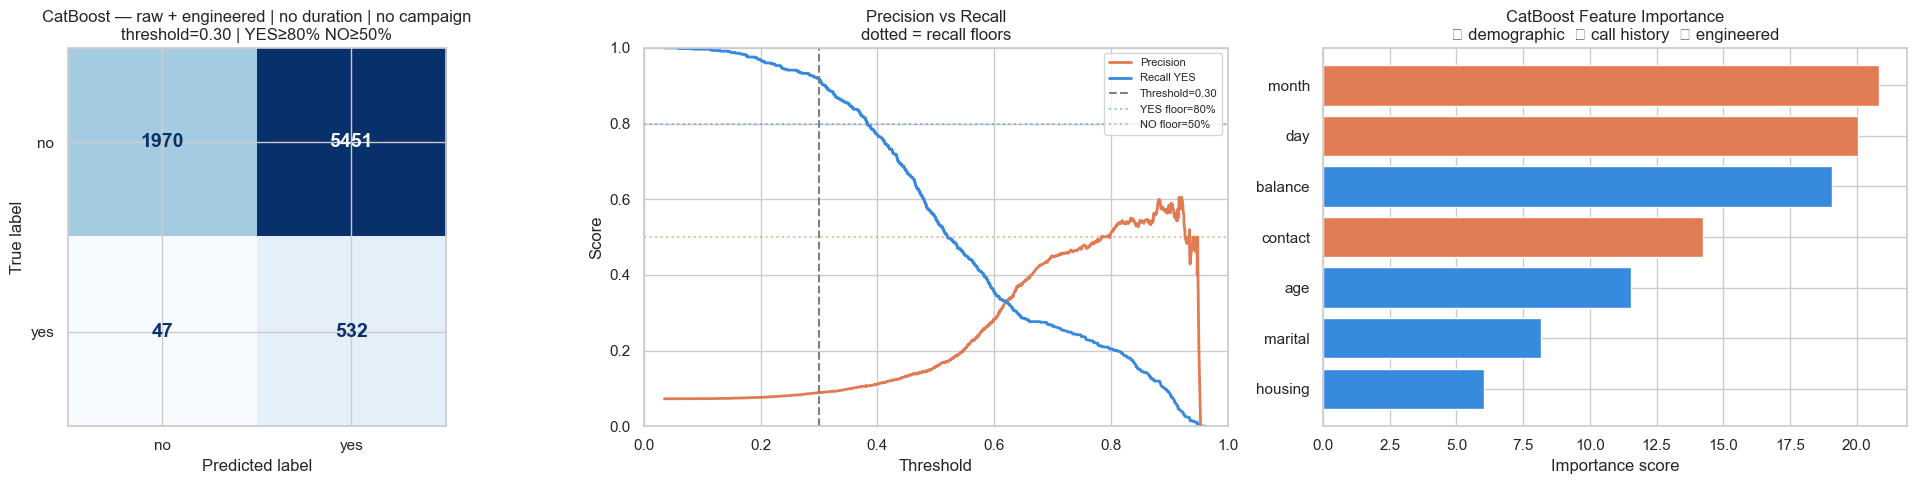

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                             confusion_matrix, precision_recall_curve,
                             roc_auc_score)
from catboost import CatBoostClassifier, Pool

# ════════════════════════════════════════════════════════════════════
# FEATURE LIST
# ════════════════════════════════════════════════════════════════════

ALL_FEATURES = [
    'day', 'month', 'contact', 'age', 'marital',
    'balance', 'housing'
]

# CatBoost handles raw strings natively — no encoding needed
# just tell it which columns are categorical
CAT_COLS = ['month', 'contact', 'marital','housing']   # string cols in ALL_FEATURES
CAT_IDX  = [ALL_FEATURES.index(c) for c in CAT_COLS]

ACTIVE_SET = "raw + engineered | no duration | no campaign"

YES_RECALL_FLOOR = 0.80
NO_RECALL_FLOOR  = 0.50

DEMO_COLS = ['age', 'job', 'marital', 'education',
             'default', 'balance', 'housing', 'loan']
CALL_COLS = ['contact', 'day', 'month', 'duration', 'campaign']

print("=" * 65)
print("   CatBoost — DUAL RECALL THRESHOLD TUNING")
print(f"   Active set       : {ACTIVE_SET}")
print(f"   YES recall floor : {YES_RECALL_FLOOR*100:.0f}%")
print(f"   NO  recall floor : {NO_RECALL_FLOOR*100:.0f}%")
print("=" * 65)
print(f"\nFeatures in use ({len(ALL_FEATURES)}) : {ALL_FEATURES}")
print(f"Categorical cols               : {CAT_COLS}")

# ── prepare data ──────────────────────────────────────────────────────
# CatBoost reads raw strings — no LabelEncoder, no get_dummies
model_df          = eda_df.copy()
model_df['y_enc'] = (model_df['y'] == 'yes').astype(int)

# force cat cols to string (handles pd.Categorical from pd.cut etc.)
for col in CAT_COLS:
    model_df[col] = model_df[col].astype(str)

X = model_df[ALL_FEATURES]
y = model_df['y_enc']

# ── train / test split ────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTrain : {X_train.shape[0]} rows "
      f"(yes: {y_train.sum()}, no: {(y_train==0).sum()})")
print(f"Test  : {X_test.shape[0]} rows "
      f"(yes: {y_test.sum()},  no: {(y_test==0).sum()})")

# ── CatBoost Pool — wraps data + cat column info ──────────────────────
train_pool = Pool(X_train, y_train, cat_features=CAT_IDX)
test_pool  = Pool(X_test,  y_test,  cat_features=CAT_IDX)

# ── train CatBoost ────────────────────────────────────────────────────
cb = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    eval_metric='AUC',
    auto_class_weights='Balanced',   # equivalent to scale_pos_weight
    early_stopping_rounds=50,
    random_seed=42,
    verbose=100
)
cb.fit(train_pool, eval_set=test_pool)

print(f"\nModel trained ✓  (best iteration: {cb.best_iteration_})")
print(f"ROC-AUC : {roc_auc_score(y_test, cb.predict_proba(test_pool)[:,1]):.4f}")

# ── dual recall threshold search ─────────────────────────────────────
y_prob = cb.predict_proba(test_pool)[:, 1]
precision_arr, recall_arr, thresholds_arr = precision_recall_curve(
    y_test, y_prob)

best_threshold = 0.3
best_yes_f1    = 0
threshold_log  = []

for thresh in np.arange(0.05, 0.80, 0.01):
    preds = (y_prob >= thresh).astype(int)
    cm_t  = confusion_matrix(y_test, preds)
    if cm_t.shape == (2, 2):
        tn_t, fp_t, fn_t, tp_t = cm_t.ravel()

        yes_rec  = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
        no_rec   = tn_t / (tn_t + fp_t) if (tn_t + fp_t) > 0 else 0
        yes_prec = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
        yes_f1   = (2 * yes_prec * yes_rec /
                    (yes_prec + yes_rec)
                    if (yes_prec + yes_rec) > 0 else 0)

        threshold_log.append({
            'threshold': round(thresh, 2),
            'yes_recall': round(yes_rec  * 100, 1),
            'no_recall' : round(no_rec   * 100, 1),
            'yes_prec'  : round(yes_prec * 100, 1),
            'yes_f1'    : round(yes_f1   * 100, 1),
            'fn'        : fn_t,
            'fp'        : fp_t,
            'valid'     : (yes_rec >= YES_RECALL_FLOOR
                           and no_rec >= NO_RECALL_FLOOR)
        })

        if (yes_rec >= YES_RECALL_FLOOR
                and no_rec >= NO_RECALL_FLOOR
                and yes_f1 > best_yes_f1):
            best_yes_f1    = yes_f1
            best_threshold = thresh

# ── threshold scan table ──────────────────────────────────────────────
print("\n" + "=" * 78)
print("   THRESHOLD SCAN — YES recall vs NO recall trade-off")
print(f"   ✅ = meets both floors "
      f"(YES≥{YES_RECALL_FLOOR*100:.0f}% AND NO≥{NO_RECALL_FLOOR*100:.0f}%)")
print("=" * 78)
print(f"  {'Thresh':>7} {'YES rec':>8} {'NO rec':>8} "
      f"{'YES prec':>9} {'YES F1':>8} {'FN':>5} {'FP':>6}")
print("-" * 78)

for row in threshold_log:
    tag = '✅' if row['valid'] else '  '
    print(f"  {tag} {row['threshold']:>5.2f}   "
          f"{row['yes_recall']:>6.1f}%  "
          f"{row['no_recall']:>6.1f}%  "
          f"{row['yes_prec']:>7.1f}%  "
          f"{row['yes_f1']:>6.1f}%  "
          f"{row['fn']:>4}  {row['fp']:>5}")

print("=" * 78)
print(f"\n  Auto-selected threshold : {best_threshold:.2f}")
print(f"  Reasoning : best YES F1 while "
      f"YES≥{YES_RECALL_FLOOR*100:.0f}% AND NO≥{NO_RECALL_FLOOR*100:.0f}%")

THRESHOLD    = best_threshold
y_pred_tuned = (y_prob >= THRESHOLD).astype(int)

# ── classification report ─────────────────────────────────────────────
print(f"\nClassification Report (threshold = {THRESHOLD:.2f}):")
print(classification_report(y_test, y_pred_tuned,
      target_names=['no', 'yes']))

# ── confusion matrix breakdown ────────────────────────────────────────
cm             = confusion_matrix(y_test, y_pred_tuned)
tn, fp, fn, tp = cm.ravel()

no_precision  = tn / (tn + fn)  if (tn + fn)  > 0 else 0
no_recall     = tn / (tn + fp)  if (tn + fp)  > 0 else 0
no_f1         = (2 * no_precision * no_recall /
                 (no_precision + no_recall)
                 if (no_precision + no_recall) > 0 else 0)
yes_precision = tp / (tp + fp)  if (tp + fp)  > 0 else 0
yes_recall    = tp / (tp + fn)  if (tp + fn)  > 0 else 0
yes_f1        = (2 * yes_precision * yes_recall /
                 (yes_precision + yes_recall)
                 if (yes_precision + yes_recall) > 0 else 0)
accuracy      = (tn + tp) / (tn + fp + fn + tp)

print("=" * 60)
print("            CONFUSION MATRIX BREAKDOWN")
print("=" * 60)
print(f"  True  Negative (TN) : {tn:>6}  — correctly predicted NO")
print(f"  False Positive (FP) : {fp:>6}  — said YES but actually NO")
print(f"  False Negative (FN) : {fn:>6}  — said NO but actually YES  ← minimise")
print(f"  True  Positive (TP) : {tp:>6}  — correctly predicted YES")
print("=" * 60)
print(f"  Overall Accuracy    : {accuracy*100:.1f}%")
print("=" * 60)
print("\n" + "=" * 60)
print("       FULL CLASSIFICATION REPORT BY CLASS")
print("=" * 60)
print(f"  {'Metric':<18} {'NO (class 0)':>15} {'YES (class 1)':>15}")
print("-" * 60)
print(f"  {'Precision':<18} {no_precision*100:>14.1f}% {yes_precision*100:>14.1f}%")
print(f"  {'Recall':<18} {no_recall*100:>14.1f}% {yes_recall*100:>14.1f}%")
print(f"  {'F1 Score':<18} {no_f1*100:>14.1f}% {yes_f1*100:>14.1f}%")
print(f"  {'Support':<18} {tn+fp:>15} {tp+fn:>15}")
print("=" * 60)
print(f"\n  ► YES recall floor set : {YES_RECALL_FLOOR*100:.0f}%")
print(f"  ► NO  recall floor set : {NO_RECALL_FLOOR*100:.0f}%")
print(f"  ► Recall YES achieved  : {yes_recall*100:.1f}%")
print(f"  ► Recall NO  achieved  : {no_recall*100:.1f}%")
print(f"  ► FN (missed yes)      : {fn}")
print(f"  ► FP (noise)           : {fp}")
print("=" * 60)

# ── feature importance ────────────────────────────────────────────────
imp_df = pd.DataFrame({
    'feature'   : ALL_FEATURES,
    'importance': cb.get_feature_importance()
}).sort_values('importance', ascending=True)

# ── plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1 — confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tuned,
    display_labels=['no', 'yes'],
    cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title(f'CatBoost — {ACTIVE_SET}\n'
                  f'threshold={THRESHOLD:.2f} | '
                  f'YES≥{YES_RECALL_FLOOR*100:.0f}% '
                  f'NO≥{NO_RECALL_FLOOR*100:.0f}%')
for text in axes[0].texts:
    text.set_fontsize(14)
    text.set_fontweight('bold')

# 2 — precision recall curve
axes[1].plot(thresholds_arr, precision_arr[:-1],
             label='Precision', color='#e07b54', linewidth=2)
axes[1].plot(thresholds_arr, recall_arr[:-1],
             label='Recall YES', color='#378add', linewidth=2)
axes[1].axvline(x=THRESHOLD, color='gray', linestyle='--',
                label=f'Threshold={THRESHOLD:.2f}')
axes[1].axhline(y=YES_RECALL_FLOOR, color='#378add',
                linestyle=':', alpha=0.5,
                label=f'YES floor={YES_RECALL_FLOOR*100:.0f}%')
axes[1].axhline(y=NO_RECALL_FLOOR, color='#e07b54',
                linestyle=':', alpha=0.5,
                label=f'NO floor={NO_RECALL_FLOOR*100:.0f}%')
axes[1].set_title('Precision vs Recall\ndotted = recall floors')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].legend(fontsize=8)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

# 3 — feature importance
colors = ['#378add' if f in DEMO_COLS
          else '#e07b54' if f in CALL_COLS
          else '#2ecc71'
          for f in imp_df['feature']]

axes[2].barh(imp_df['feature'], imp_df['importance'],
             color=colors, edgecolor='white')
axes[2].set_title('CatBoost Feature Importance\n'
                  '🔵 demographic  🟠 call history  🟢 engineered')
axes[2].set_xlabel('Importance score')

plt.tight_layout()
plt.show()

# CatBoost and RandomForest

   STACK — Random Forest + CatBoost → LR meta
   Features         : ['day', 'month', 'contact', 'age', 'marital', 'balance', 'housing']
   YES recall floor : 80%
   NO  recall floor : 50%

X_rf shape : (40000, 7)  (label-encoded for RF)
X_cb shape : (40000, 7)  (raw strings for CatBoost)

Train : 32000  (yes=2317, no=29683)
Test  : 8000   (yes=579, no=7421)

── Generating 5-fold OOF predictions ──
  Fold 1 — RF AUC: 0.683  CB AUC: 0.701
  Fold 2 — RF AUC: 0.698  CB AUC: 0.706
  Fold 3 — RF AUC: 0.706  CB AUC: 0.714
  Fold 4 — RF AUC: 0.693  CB AUC: 0.720
  Fold 5 — RF AUC: 0.707  CB AUC: 0.720

OOF AUC — RF : 0.6971
OOF AUC — CB : 0.7117

── Complementarity check (OOF) ──
  RF false positives (wrong NO)   : 17399
  CB corrects them   (says NO)    : 192  (1.1%)

  RF false negatives (missed YES) : 457
  CB catches them    (says YES)   : 297  (65.0%)
  → higher % = more complementary = better stack potential

── Training final base models on full train set ──
Base models trained ✓

  Tes

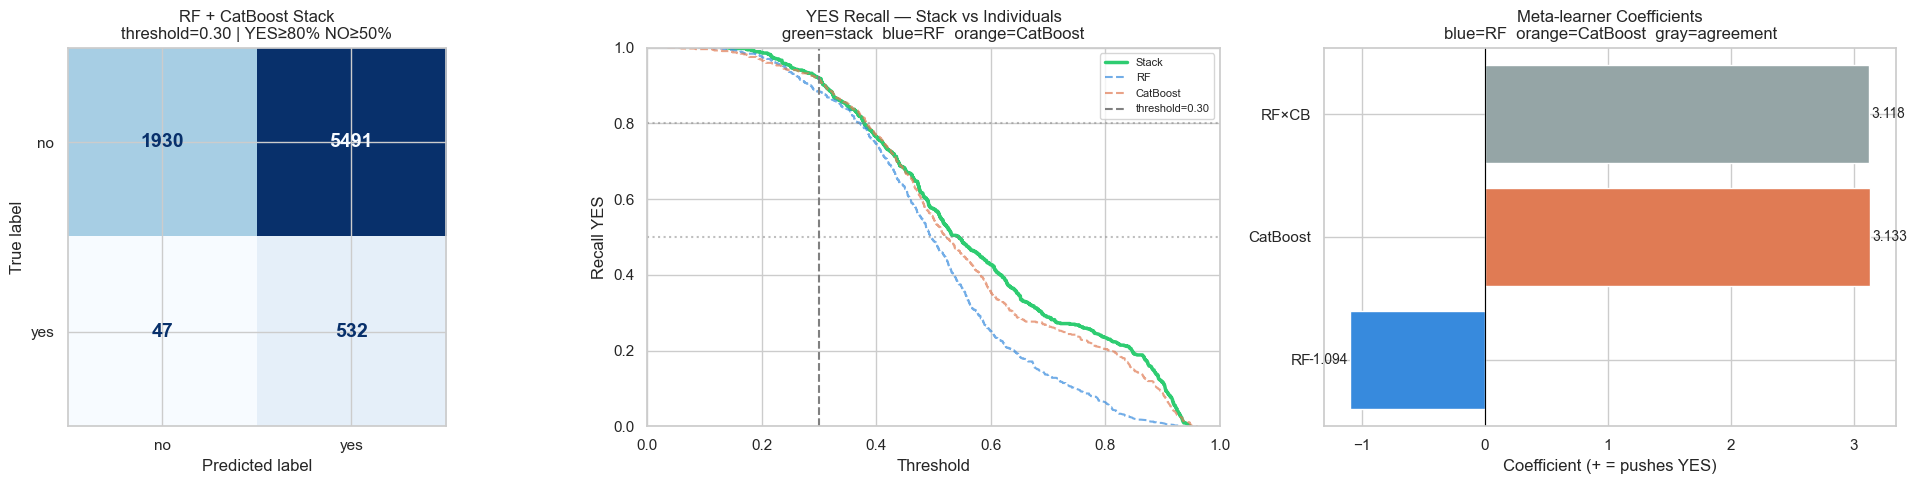

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                             confusion_matrix, precision_recall_curve,
                             roc_auc_score)
from catboost import CatBoostClassifier, Pool

# ════════════════════════════════════════════════════════════════════
# FEATURE LIST — same as both individual models
# ════════════════════════════════════════════════════════════════════

ALL_FEATURES = [
    'day', 'month', 'contact', 'age', 'marital',
    'balance', 'housing'
]

CAT_COLS = ['month', 'contact', 'marital', 'housing']
CAT_IDX  = [ALL_FEATURES.index(c) for c in CAT_COLS]

YES_RECALL_FLOOR = 0.80
NO_RECALL_FLOOR  = 0.50

DEMO_COLS = ['age', 'job', 'marital', 'education',
             'default', 'balance', 'housing', 'loan']
CALL_COLS = ['contact', 'day', 'month', 'duration', 'campaign']

print("=" * 65)
print("   STACK — Random Forest + CatBoost → LR meta")
print(f"   Features         : {ALL_FEATURES}")
print(f"   YES recall floor : {YES_RECALL_FLOOR*100:.0f}%")
print(f"   NO  recall floor : {NO_RECALL_FLOOR*100:.0f}%")
print("=" * 65)

# ════════════════════════════════════════════════════════════════════
# DATA PREP — two versions of X
# X_rf : label-encoded ints  → RandomForest
# X_cb : raw strings         → CatBoost Pool
# ════════════════════════════════════════════════════════════════════

model_df          = eda_df.copy()
model_df['y_enc'] = (model_df['y'] == 'yes').astype(int)

# ── X_cb: force cat cols to string ────────────────────────────────────
for col in CAT_COLS:
    model_df[col] = model_df[col].astype(str)

X_cb = model_df[ALL_FEATURES].copy()

# ── X_rf: label-encode cat cols for RF ───────────────────────────────
le = LabelEncoder()
model_rf = model_df.copy()
for col in CAT_COLS:
    model_rf[col] = le.fit_transform(model_rf[col].astype(str))

X_rf = model_rf[ALL_FEATURES].values.astype(np.float32)
X_cb = X_cb.values
y    = model_df['y_enc'].values

print(f"\nX_rf shape : {X_rf.shape}  (label-encoded for RF)")
print(f"X_cb shape : {X_cb.shape}  (raw strings for CatBoost)")

# ── same train/test indices for both ─────────────────────────────────
idx = np.arange(len(y))
tr_idx, te_idx = train_test_split(
    idx, test_size=0.2, random_state=42, stratify=y)

X_rf_train, X_rf_test = X_rf[tr_idx], X_rf[te_idx]
X_cb_train, X_cb_test = X_cb[tr_idx], X_cb[te_idx]
y_train,     y_test   = y[tr_idx],    y[te_idx]

print(f"\nTrain : {len(y_train)}  (yes={y_train.sum()}, no={(y_train==0).sum()})")
print(f"Test  : {len(y_test)}   (yes={y_test.sum()}, no={(y_test==0).sum()})")

# ════════════════════════════════════════════════════════════════════
# STEP 1 — OOF predictions (5-fold)
# ════════════════════════════════════════════════════════════════════

N_FOLDS = 5
skf     = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_rf = np.zeros(len(y_train))
oof_cb = np.zeros(len(y_train))

print(f"\n── Generating {N_FOLDS}-fold OOF predictions ──")

for fold, (f_tr, f_val) in enumerate(skf.split(X_rf_train, y_train), 1):

    yf_tr, yf_val = y_train[f_tr], y_train[f_val]

    # ── Random Forest fold ────────────────────────────────────────────
    rf_fold = RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=5,
        max_features='sqrt', class_weight='balanced',
        random_state=42, n_jobs=-1)
    rf_fold.fit(X_rf_train[f_tr], yf_tr)
    oof_rf[f_val] = rf_fold.predict_proba(X_rf_train[f_val])[:, 1]

    # ── CatBoost fold ─────────────────────────────────────────────────
    cb_tr_pool  = Pool(X_cb_train[f_tr],  yf_tr,  cat_features=CAT_IDX)
    cb_val_pool = Pool(X_cb_train[f_val], yf_val, cat_features=CAT_IDX)

    cb_fold = CatBoostClassifier(
        iterations=500, learning_rate=0.05, depth=6,
        eval_metric='AUC', auto_class_weights='Balanced',
        early_stopping_rounds=30, random_seed=42,
        thread_count=-1, verbose=0, allow_writing_files=False)
    cb_fold.fit(cb_tr_pool, eval_set=cb_val_pool)
    oof_cb[f_val] = cb_fold.predict_proba(cb_val_pool)[:, 1]

    print(f"  Fold {fold} — RF AUC: {roc_auc_score(yf_val, oof_rf[f_val]):.3f}  "
          f"CB AUC: {roc_auc_score(yf_val, oof_cb[f_val]):.3f}")

print(f"\nOOF AUC — RF : {roc_auc_score(y_train, oof_rf):.4f}")
print(f"OOF AUC — CB : {roc_auc_score(y_train, oof_cb):.4f}")

# ── complementarity check ─────────────────────────────────────────────
rf_oof_pred = (oof_rf >= 0.35).astype(int)
cb_oof_pred = (oof_cb >= 0.30).astype(int)

fp_mask = (y_train == 0) & (rf_oof_pred == 1)   # RF's false positives
fn_mask = (y_train == 1) & (rf_oof_pred == 0)   # RF's missed YES

print(f"\n── Complementarity check (OOF) ──")
print(f"  RF false positives (wrong NO)   : {fp_mask.sum()}")
print(f"  CB corrects them   (says NO)    : {(cb_oof_pred[fp_mask]==0).sum()}  "
      f"({(cb_oof_pred[fp_mask]==0).sum()/max(fp_mask.sum(),1)*100:.1f}%)")
print(f"\n  RF false negatives (missed YES) : {fn_mask.sum()}")
print(f"  CB catches them    (says YES)   : {(cb_oof_pred[fn_mask]==1).sum()}  "
      f"({(cb_oof_pred[fn_mask]==1).sum()/max(fn_mask.sum(),1)*100:.1f}%)")
print("  → higher % = more complementary = better stack potential")

# ════════════════════════════════════════════════════════════════════
# STEP 2 — final base models on full train set
# ════════════════════════════════════════════════════════════════════

print("\n── Training final base models on full train set ──")

rf_final = RandomForestClassifier(
    n_estimators=300, max_depth=10, min_samples_leaf=5,
    max_features='sqrt', class_weight='balanced',
    random_state=42, n_jobs=-1)
rf_final.fit(X_rf_train, y_train)

train_pool = Pool(X_cb_train, y_train, cat_features=CAT_IDX)
test_pool  = Pool(X_cb_test,  y_test,  cat_features=CAT_IDX)

cb_final = CatBoostClassifier(
    iterations=1000, learning_rate=0.05, depth=6,
    eval_metric='AUC', auto_class_weights='Balanced',
    early_stopping_rounds=50, random_seed=42,
    thread_count=-1, verbose=0, allow_writing_files=False)
cb_final.fit(train_pool, eval_set=test_pool)

print("Base models trained ✓")

test_rf = rf_final.predict_proba(X_rf_test)[:, 1]
test_cb = cb_final.predict_proba(test_pool)[:, 1]

print(f"\n  Test AUC — RF : {roc_auc_score(y_test, test_rf):.4f}")
print(f"  Test AUC — CB : {roc_auc_score(y_test, test_cb):.4f}")

# ════════════════════════════════════════════════════════════════════
# STEP 3 — meta-learner
# features: [rf_prob, cb_prob, rf*cb agreement term]
# ════════════════════════════════════════════════════════════════════

meta_train = np.column_stack([oof_rf, oof_cb, oof_rf * oof_cb])
meta_test  = np.column_stack([test_rf, test_cb, test_rf * test_cb])

meta_lr = LogisticRegression(
    C=1.0, class_weight='balanced',
    random_state=42, max_iter=1000)
meta_lr.fit(meta_train, y_train)

coef_labels = ['RF', 'CatBoost', 'RF×CB']
print("\n── Meta-learner coefficients ──")
for label, coef in zip(coef_labels, meta_lr.coef_[0]):
    bar = '█' * int(abs(coef) * 10)
    print(f"  {label:<12} : {coef:+.4f}  {bar}")
print("  (+ = pushes toward YES)")

y_prob_stack = meta_lr.predict_proba(meta_test)[:, 1]
print(f"\n  Stack AUC : {roc_auc_score(y_test, y_prob_stack):.4f}")

# ════════════════════════════════════════════════════════════════════
# STEP 4 — threshold scan
# ════════════════════════════════════════════════════════════════════

precision_arr, recall_arr, thresholds_arr = precision_recall_curve(
    y_test, y_prob_stack)

best_threshold = 0.3
best_yes_f1    = 0
threshold_log  = []

for thresh in np.arange(0.05, 0.80, 0.01):
    preds = (y_prob_stack >= thresh).astype(int)
    cm_t  = confusion_matrix(y_test, preds)
    if cm_t.shape == (2, 2):
        tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
        yes_rec  = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
        no_rec   = tn_t / (tn_t + fp_t) if (tn_t + fp_t) > 0 else 0
        yes_prec = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
        yes_f1   = (2 * yes_prec * yes_rec / (yes_prec + yes_rec)
                    if (yes_prec + yes_rec) > 0 else 0)

        threshold_log.append({
            'threshold' : round(thresh, 2),
            'yes_recall': round(yes_rec  * 100, 1),
            'no_recall' : round(no_rec   * 100, 1),
            'yes_prec'  : round(yes_prec * 100, 1),
            'yes_f1'    : round(yes_f1   * 100, 1),
            'fn': fn_t, 'fp': fp_t,
            'valid': (yes_rec >= YES_RECALL_FLOOR and no_rec >= NO_RECALL_FLOOR)
        })

        if (yes_rec >= YES_RECALL_FLOOR and no_rec >= NO_RECALL_FLOOR
                and yes_f1 > best_yes_f1):
            best_yes_f1    = yes_f1
            best_threshold = thresh

print("\n" + "=" * 78)
print("   THRESHOLD SCAN")
print(f"   ✅ = YES≥{YES_RECALL_FLOOR*100:.0f}% AND NO≥{NO_RECALL_FLOOR*100:.0f}%")
print("=" * 78)
print(f"  {'Thresh':>7} {'YES rec':>8} {'NO rec':>8} "
      f"{'YES prec':>9} {'YES F1':>8} {'FN':>5} {'FP':>6}")
print("-" * 78)
for row in threshold_log:
    tag = '✅' if row['valid'] else '  '
    print(f"  {tag} {row['threshold']:>5.2f}   "
          f"{row['yes_recall']:>6.1f}%  {row['no_recall']:>6.1f}%  "
          f"{row['yes_prec']:>7.1f}%  {row['yes_f1']:>6.1f}%  "
          f"{row['fn']:>4}  {row['fp']:>5}")
print("=" * 78)
print(f"\n  Auto-selected threshold : {best_threshold:.2f}")

THRESHOLD    = best_threshold
y_pred_tuned = (y_prob_stack >= THRESHOLD).astype(int)

cm             = confusion_matrix(y_test, y_pred_tuned)
tn, fp, fn, tp = cm.ravel()
no_recall      = tn / (tn + fp)  if (tn + fp)  > 0 else 0
yes_recall     = tp / (tp + fn)  if (tp + fn)  > 0 else 0
no_precision   = tn / (tn + fn)  if (tn + fn)  > 0 else 0
yes_precision  = tp / (tp + fp)  if (tp + fp)  > 0 else 0
no_f1          = (2*no_precision*no_recall/(no_precision+no_recall)
                  if (no_precision+no_recall) > 0 else 0)
yes_f1         = (2*yes_precision*yes_recall/(yes_precision+yes_recall)
                  if (yes_precision+yes_recall) > 0 else 0)
accuracy       = (tn + tp) / (tn + fp + fn + tp)

print(f"\nClassification Report (threshold={THRESHOLD:.2f}):")
print(classification_report(y_test, y_pred_tuned, target_names=['no','yes']))
print("=" * 60)
print(f"  TN={tn}  FP={fp}  FN={fn}  TP={tp}  Acc={accuracy*100:.1f}%")
print(f"  YES recall : {yes_recall*100:.1f}%   NO recall : {no_recall*100:.1f}%")
print(f"  FN : {fn}   FP : {fp}")
print("=" * 60)

# ── comparison table ──────────────────────────────────────────────────
print("\n" + "=" * 65)
print("   STACK vs INDIVIDUAL MODELS")
print("=" * 65)
print(f"  {'Model':<22} {'YES rec':>8} {'NO rec':>8} {'FN':>6} {'FP':>7}")
print("-" * 65)

def show_row(prob, thr, label):
    pred = (prob >= thr).astype(int)
    tn_,fp_,fn_,tp_ = confusion_matrix(y_test, pred).ravel()
    yr = tp_/(tp_+fn_) if (tp_+fn_) > 0 else 0
    nr = tn_/(tn_+fp_) if (tn_+fp_) > 0 else 0
    tag = '✅' if (yr >= YES_RECALL_FLOOR and nr >= NO_RECALL_FLOOR) else '  '
    print(f"  {tag} {label:<20} {yr*100:>7.1f}% {nr*100:>8.1f}% {fn_:>6} {fp_:>7}")

show_row(test_rf,      0.35, 'RF (0.35)')
show_row(test_cb,      0.30, 'CatBoost (0.30)')
show_row(y_prob_stack, THRESHOLD, f'Stack ({THRESHOLD:.2f})')
print("=" * 65)

# ════════════════════════════════════════════════════════════════════
# PLOTS
# ════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1 — confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tuned,
    display_labels=['no', 'yes'],
    cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title(f'RF + CatBoost Stack\n'
                  f'threshold={THRESHOLD:.2f} | '
                  f'YES≥{YES_RECALL_FLOOR*100:.0f}% '
                  f'NO≥{NO_RECALL_FLOOR*100:.0f}%')
for text in axes[0].texts:
    text.set_fontsize(14)
    text.set_fontweight('bold')

# 2 — recall curves: stack vs individuals
prec_r, rec_r, thr_r = precision_recall_curve(y_test, test_rf)
prec_c, rec_c, thr_c = precision_recall_curve(y_test, test_cb)

axes[1].plot(thresholds_arr, recall_arr[:-1],
             label='Stack', color='#2ecc71', linewidth=2.5)
axes[1].plot(thr_r, rec_r[:-1], label='RF',
             color='#378add', linewidth=1.5, alpha=0.7, linestyle='--')
axes[1].plot(thr_c, rec_c[:-1], label='CatBoost',
             color='#e07b54', linewidth=1.5, alpha=0.7, linestyle='--')
axes[1].axvline(x=THRESHOLD, color='gray', linestyle='--',
                label=f'threshold={THRESHOLD:.2f}')
axes[1].axhline(y=YES_RECALL_FLOOR, color='gray', linestyle=':', alpha=0.5)
axes[1].axhline(y=NO_RECALL_FLOOR,  color='gray', linestyle=':', alpha=0.5)
axes[1].set_title('YES Recall — Stack vs Individuals\n'
                  'green=stack  blue=RF  orange=CatBoost')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Recall YES')
axes[1].legend(fontsize=8)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

# 3 — meta-learner coefficients
bar_colors = ['#378add', '#e07b54', '#95a5a6']
axes[2].barh(coef_labels, meta_lr.coef_[0],
             color=bar_colors, edgecolor='white')
axes[2].axvline(x=0, color='black', linewidth=0.8)
axes[2].set_title('Meta-learner Coefficients\n'
                  'blue=RF  orange=CatBoost  gray=agreement')
axes[2].set_xlabel('Coefficient (+ = pushes YES)')
for i, v in enumerate(meta_lr.coef_[0]):
    axes[2].text(v + (0.02 if v >= 0 else -0.02), i,
                 f'{v:.3f}', va='center',
                 ha='left' if v >= 0 else 'right', fontsize=10)

plt.tight_layout()
plt.show()

In [24]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_auc_score
from catboost import CatBoostClassifier, Pool

# ════════════════════════════════════════════════════════════════════
# LAYER 1 — CatBoost  (same setup that produced the 91.9% YES recall)
# Purpose: re-run, then export the predicted-YES pool for Layer 2
# ════════════════════════════════════════════════════════════════════

# Layer 1 features  (NO duration, NO campaign)
L1_FEATURES = ['day', 'month', 'contact', 'age', 'marital', 'balance', 'housing']
CAT_COLS    = ['month', 'contact', 'marital', 'housing']
CAT_IDX     = [L1_FEATURES.index(c) for c in CAT_COLS]

# Layer 2 will need these — keep them in the exported CSV
L2_EXTRA    = ['duration', 'campaign']

L1_THRESHOLD = 0.30   # same threshold that gave 91.9% YES recall

print("=" * 65)
print("   LAYER 1  —  CatBoost extraction")
print(f"   Features   : {L1_FEATURES}")
print(f"   Threshold  : {L1_THRESHOLD}")
print(f"   Extra cols saved for Layer 2 : {L2_EXTRA}")
print("=" * 65)

# ── prepare data ──────────────────────────────────────────────────────
model_df          = eda_df.copy()
model_df['y_enc'] = (model_df['y'] == 'yes').astype(int)

for col in CAT_COLS:
    model_df[col] = model_df[col].astype(str)

X   = model_df[L1_FEATURES]
y   = model_df['y_enc']
idx = model_df.index   # keep original row indices

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, idx, test_size=0.2, random_state=42, stratify=y)

train_pool = Pool(X_train, y_train, cat_features=CAT_IDX)
test_pool  = Pool(X_test,  y_test,  cat_features=CAT_IDX)

# ── train Layer 1 ─────────────────────────────────────────────────────
cb_l1 = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    eval_metric='AUC',
    auto_class_weights='Balanced',
    early_stopping_rounds=50,
    random_seed=42,
    verbose=100
)
cb_l1.fit(train_pool, eval_set=test_pool)

auc = roc_auc_score(y_test, cb_l1.predict_proba(test_pool)[:, 1])
print(f"\nLayer 1 trained  ✓   best iter={cb_l1.best_iteration_}   AUC={auc:.4f}")

# ── apply threshold ───────────────────────────────────────────────────
y_prob_test = cb_l1.predict_proba(test_pool)[:, 1]
y_pred_test = (y_prob_test >= L1_THRESHOLD).astype(int)

cm             = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()
yes_recall     = tp / (tp + fn)
no_recall      = tn / (tn + fp)

print("\n" + "=" * 60)
print("   LAYER 1  —  TEST SET RESULTS")
print("=" * 60)
print(f"  TN={tn}  FP={fp}  FN={fn}  TP={tp}")
print(f"  YES recall : {yes_recall*100:.1f}%   (target ≥80%)")
print(f"  NO  recall : {no_recall*100:.1f}%   (target ≥50%)")
print(f"\n  Predicted YES pool : {fp + tp} rows  (= TP {tp} + FP {fp})")
print(f"  Permanently missed : {fn} real YES  ← these never reach Layer 2")
print(f"  Eliminated upfront : {tn} real NO   ← saved from wasted calls")
print("=" * 60)

# ════════════════════════════════════════════════════════════════════
# EXPORT — all rows predicted YES on the test set
# These carry the true label (y_enc) + duration + campaign for Layer 2
# ════════════════════════════════════════════════════════════════════

# Identify test rows predicted as YES
pos_mask      = y_pred_test == 1
pos_idx       = idx_test[pos_mask]          # original DataFrame indices

# Build export DataFrame: Layer 1 features + L2 extras + probability + true label
export_df = model_df.loc[pos_idx, L1_FEATURES + L2_EXTRA + ['y_enc']].copy()
export_df['l1_prob']  = y_prob_test[pos_mask]   # Layer 1 score (for reference)
export_df['true_yes'] = export_df['y_enc']       # alias for clarity

print(f"\nExport shape : {export_df.shape}")
print(f"  TRUE  yes in pool : {export_df['true_yes'].sum()}  "
      f"({export_df['true_yes'].mean()*100:.1f}%)")
print(f"  FALSE yes in pool : {(export_df['true_yes']==0).sum()}  "
      f"({(export_df['true_yes']==0).mean()*100:.1f}%)")
print(f"\nFirst 5 rows of export:")
print(export_df.head())

OUTPUT_PATH = 'layer1_positives.csv'
export_df.to_csv(OUTPUT_PATH, index=False)
print(f"\n✅  Saved →  {OUTPUT_PATH}")
print(f"    Rows    : {len(export_df)}")
print(f"    Columns : {list(export_df.columns)}")

# ── story recap ───────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("   TWO-LAYER STORY")
print("=" * 65)
print(f"  Full test set          : {len(y_test)} people")
print(f"  Layer 1 eliminates     : {tn} definite NO → no call needed")
print(f"  Layer 1 flags          : {fp+tp} for calling  → go to Layer 2")
print(f"    of which truly YES   : {tp}  (we want to keep these)")
print(f"    of which truly NO    : {fp}  (Layer 2 should reject these)")
print(f"  Missed YES (FN)        : {fn}  → permanently lost")
print("=" * 65)
print("\nNext: run layer2_model.py on layer1_positives.csv")
print("      Layer 2 adds duration + campaign to filter out the", fp, "false positives")


   LAYER 1  —  CatBoost extraction
   Features   : ['day', 'month', 'contact', 'age', 'marital', 'balance', 'housing']
   Threshold  : 0.3
   Extra cols saved for Layer 2 : ['duration', 'campaign']
0:	test: 0.6441845	best: 0.6441845 (0)	total: 59ms	remaining: 59s
100:	test: 0.7221158	best: 0.7221453 (98)	total: 9.77s	remaining: 1m 26s
200:	test: 0.7256829	best: 0.7257623 (198)	total: 18.5s	remaining: 1m 13s
300:	test: 0.7286575	best: 0.7287506 (299)	total: 29.2s	remaining: 1m 7s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7294252482
bestIteration = 324

Shrink model to first 325 iterations.

Layer 1 trained  ✓   best iter=324   AUC=0.7294

   LAYER 1  —  TEST SET RESULTS
  TN=1970  FP=5451  FN=47  TP=532
  YES recall : 91.9%   (target ≥80%)
  NO  recall : 26.5%   (target ≥50%)

  Predicted YES pool : 5983 rows  (= TP 532 + FP 5451)
  Permanently missed : 47 real YES  ← these never reach Layer 2
  Eliminated upfront : 1970 real NO   ← saved from wasted calls

Exp